# Alpha Steel Final Techincal Report - Andrea Estabrook

----

## Introduction

The dataset selected for this project is from Alpha Steel, a multi-platform, multi-site producer of steel and steel-derived products. Operating across 10 countries in the Americas, Alpha Steel’s manufacturing process is fully integrated, encompassing everything from iron ore extraction to the production of high-value steel products for key industrial sectors. The company has 8 production plants in the United States and mining facilities in Mexico, with an annual production capacity of 9.5 million tons of hot-rolled coil.

Alpha Steel serves diverse industries, including construction, automotive, home appliances, agroindustry, packaging, transport, and energy. The company’s product portfolio includes flat steel (hot-rolled, cold-rolled), coated steel (galvanized, pre-painted, aluminum alloy coatings), welded tubes, structural shapes, long steel (rebars, wire rods), and tinplate.

This dataset specifically focuses on Alpha Steel’s web-based digital sales platform, which was launched in 2016 to automate the order-to-purchase cycle and reduce reliance on human-operated customer service. Clients interact with the system in different ways, leading to four key classifications:

* Browser: Clients who log in but do not select any products.
* Selector: Clients who select products to check availability but do not request a quote.
* Quote-only: Clients who add products to the cart and request pricing but do not finalize the purchase.
* Buyer: Clients who complete the purchasing process, set payment methods, and choose pick-up or delivery.

These classifications serve as key performance metrics for evaluating the effectiveness of the web system. By analyzing client interactions within this dataset, we can gain insights into customer behavior, engagement patterns, and factors influencing purchase decisions in the steel industry.

This dataset presents an opportunity to apply machine learning techniques to analyze client engagement and optimize conversion rates from browsing to purchasing, ultimately enhancing Alpha Steel’s digital sales strategy.

#### Dataset Variables

| Variable Name                          | Measurement Type    | Role       |
|----------------------------------------|--------------------|------------|
| ID_CLIENT                              | Categorical        | Excluded   |
| SESSIONS_YEAR                          | Numeric           | Predictor  |
| AVERAGE_ACTIONS                        | Numeric           | Predictor  |
| NUMBER_OF_PURCHASES                    | Numeric           | Predictor  |
| CHANGE_DISTCENTER                      | Numeric           | Predictor  |
| MAXNUMBER_PAGES_VISITED                | Numeric           | Predictor  |
| AVGNUMBER_PAGES_VISITED                | Numeric           | Predictor  |
| TONS_ONCART                            | Numeric           | Predictor  |
| TONS_CONFIRMED                         | Numeric           | Predictor  |
| DELIVERY_OR_PICKUP                     | Categorical       | Predictor  |
| SESSIONS_ONWEBAPP                      | Numeric           | Predictor  |
| SESSIONS_ATTENDED_BYEXECUTIVE          | Numeric           | Predictor  |
| USE_OF_EXCEL_TOOL                      | Binary            | Predictor  |
| USE_OF_CLIENT_CATALOGUE                | Binary            | Predictor  |
| NUMBER_OF_NEGOTIATIONS                 | Numeric           | Predictor  |
| USE_OF_PROPOSAL                        | Binary            | Predictor  |
| CONSTRUCTION_INDEX                     | Numeric           | Predictor  |
| MANUFACTURING_INDEX                    | Numeric           | Predictor  |
| MONTHS_AS_CLIENT                       | Numeric           | Predictor  |
| NUMBER_MONTHS_AS_REGISTEREDCLIENT      | Numeric           | Predictor  |
| CLASSIFICATION                         | Categorical       | Outcome    |
| MONTH                                  | Time-based        | Predictor  |
| YEAR                                   | Time-based        | Predictor  |

#### Research Goal

This project aims to analyze client interactions on Alpha Steel’s web-based digital sales platform to identify key factors influencing customer classification into engagement categories (Buyer, Selector, Quote-only, and Browser). By leveraging machine learning techniques, the study will explore how usage patterns—such as session frequency, average actions, and purchase behavior—correlate with conversion rates. Additionally, the project will examine whether client behavior metrics, including order volume and fulfillment preferences (delivery/pickup), can serve as predictors of long-term customer retention and satisfaction. The insights derived will inform strategies to optimize Alpha Steel’s digital sales approach and enhance overall customer engagement.

## Installing and Importing required libraries

In [39]:
# --- Install Required Libraries ---

# --- Data Handling ---
# Required for managing Excel file uploads
%pip install pandas openpyxl

# --- Scientific Computing ---
# Provides advanced mathematical and statistical functions
%pip install scipy  

# --- Generalized Additive Models (GAM) ---
# Required for running GAM models
%pip install pygam  

# --- Deep Learning ---
# Required for deep learning models with Keras
%pip install tensorflow  

print("\n✅ All libraries were installed.")

Note: you may need to restart the kernel to use updated packages.

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.

✅ All libraries were installed.


In [1]:
# --- Import Required Libraries ---

# --- Data Handling ---
import numpy as np  # Numerical computing
import pandas as pd  # Data manipulation
pd.options.display.float_format = '{:.3f}'.format  # Set float display to 3 decimal places

# --- Data Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display  # For displaying DataFrames in Jupyter Notebooks

# Improve Seaborn visualizations
sns.set()

# Enable inline plotting (ONLY for Jupyter Notebook users)
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass  # Ignore if running outside Jupyter

# --- Pandas Display Options ---
pd.set_option("display.max_columns", None)  # Show all columns
pd.set_option("display.max_rows", 200)  # Set row display limit

# --- Statistical Analysis & Hypothesis Testing ---
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.anova import anova_lm
from scipy import stats  # Includes z-score standardization

# --- Machine Learning: Preprocessing & Model Selection ---
from sklearn.preprocessing import StandardScaler, LabelEncoder  # Standardization & Label Encoding
from sklearn.utils.class_weight import compute_class_weight  # Compute class weights for imbalanced data
from imblearn.over_sampling import SMOTE  # Synthetic Minority Over-sampling Technique for balancing
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, KFold, cross_val_score
from sklearn.impute import SimpleImputer  # Handle missing values

# --- Dimensionality Reduction & Clustering ---
from sklearn.decomposition import PCA  # Principal Component Analysis
from sklearn.cluster import KMeans  # KMeans Clustering
from sklearn.metrics import silhouette_score  # Silhouette Score for Cluster Evaluation

# --- Initialize Scaler ---
scaler = StandardScaler()

# --- Machine Learning Models ---
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

# --- Model Evaluation Metrics ---
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    mean_squared_error,
    r2_score,
    f1_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    roc_curve
)

# --- Generalized Additive Models (GAM) ---
from pygam import LinearGAM

# --- Deep Learning (TensorFlow/Keras) ---
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical  # One-hot encoding for classification targets
from tensorflow.keras.callbacks import EarlyStopping  # Stop training if validation loss stops improving
from tensorflow.keras.optimizers import Adam  # Optimizer for neural networks

# --- Additional Utilities ---
from collections import Counter  # For checking class distribution after balancing

# --- Suppress Future Warnings ---
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

print("\n✅ All libraries were imported.")



✅ All libraries were imported.


----

## Exploratory Data Analysis

#### Initial Data Inspection

In [2]:
# --- Load Dataset ---
database = pd.read_excel(r'C:\Users\andre\OneDrive\Desktop\School\2025 Spring1 CIS4250 Suvey of Machine Learning\Project Information\STEELMANUF_CLIENTS_SV.xlsx', sheet_name='DB')

# --- Preview the Data ---
display(database.head())  # Show the first five rows
display(database.tail())  # Show the last five rows

# --- Dataset Information ---
database.info()  # Display dataset structure, column types, and non-null counts

# --- Check Dataset Shape ---
print(f"There are {database.shape[0]} rows and {database.shape[1]} columns.")

,ID_CLIENT,SESSIONS_YEAR,AVERAGE_ACTIONS,NUMBER_OF_PURCHASES,CHANGE_DISTCENTER,MAXNUMBER_PAGES_VISITED,AVGNUMBER_PAGES_VISITED,TONS_ONCART,TONS_CONFIRMED,DELIVERY_OR_PICKUP,SESSIONS_ONWEBAPP,SESSIONS_ATTENDED_BYEXECUTIVE,USE_OF_EXCEL_TOOL,USE_OF_CLIENT_CATALOGUE,NUMBER_OF_NEGOTIATIONS,USE_OF_PROPOSAL,CONSTRUCTION_INDEX,MANUFACTURING_INDEX,MONTHS_AS_CLIENT,NUMBER_MONTHS_AS_REGISTEREDCLIENT,CLASSIFICATION,MONTH,YEAR
0,896397,13,14.538,4,12,7,1,45.390,45.390,2,6,7,0,0,0,0,107.919,124.311,111,111,Buyer,8,2017
1,988398,29,11.069,9,18,12,3,57.940,57.940,2,29,0,0,0,7,0,102.309,118.543,101,101,Selector,8,2017
2,957974,4,1.250,0,0,2,0,10.710,10.710,0,4,0,0,0,1,0,115.106,106.574,9,9,Selector,8,2017
3,951495,1,16.000,0,0,4,4,6.050,6.050,0,1,0,0,0,1,0,102.840,129.212,38,38,Quote-only,8,2017
4,136560,3,7.333,0,0,0,0,0.000,0.000,0,3,0,0,0,0,0,112.763,146.941,25,25,Browser,8,2017


,ID_CLIENT,SESSIONS_YEAR,AVERAGE_ACTIONS,NUMBER_OF_PURCHASES,CHANGE_DISTCENTER,MAXNUMBER_PAGES_VISITED,AVGNUMBER_PAGES_VISITED,TONS_ONCART,TONS_CONFIRMED,DELIVERY_OR_PICKUP,SESSIONS_ONWEBAPP,SESSIONS_ATTENDED_BYEXECUTIVE,USE_OF_EXCEL_TOOL,USE_OF_CLIENT_CATALOGUE,NUMBER_OF_NEGOTIATIONS,USE_OF_PROPOSAL,CONSTRUCTION_INDEX,MANUFACTURING_INDEX,MONTHS_AS_CLIENT,NUMBER_MONTHS_AS_REGISTEREDCLIENT,CLASSIFICATION,MONTH,YEAR
17939,259827,18,29.333,7,0,1,0,315.590,235.310,2,16,2,0,0,0,1,115.917,119.349,68,68,Buyer,6,2020
17940,711689,2,25.500,0,0,2,2,7.720,7.720,0,1,1,0,0,2,0,91.008,92.155,55,55,Quote-only,6,2020
17941,959604,2,3.000,0,0,0,0,0.000,0.000,0,0,2,0,0,0,0,98.202,125.641,43,43,Browser,6,2020
17942,147431,15,20.067,8,0,4,1,84.810,84.810,2,15,0,0,0,9,1,63.146,74.363,110,110,Buyer,6,2020
17943,175773,13,24.077,0,0,0,0,0.000,0.000,0,13,0,2,0,0,0,113.775,123.209,32,32,Quote-only,6,2020


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17944 entries, 0 to 17943
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   ID_CLIENT                          17944 non-null  int64  
 1   SESSIONS_YEAR                      17944 non-null  int64  
 2   AVERAGE_ACTIONS                    17944 non-null  float64
 3   NUMBER_OF_PURCHASES                17944 non-null  int64  
 4   CHANGE_DISTCENTER                  17944 non-null  int64  
 5   MAXNUMBER_PAGES_VISITED            17944 non-null  int64  
 6   AVGNUMBER_PAGES_VISITED            17944 non-null  int64  
 7   TONS_ONCART                        17944 non-null  float64
 8   TONS_CONFIRMED                     17944 non-null  float64
 9   DELIVERY_OR_PICKUP                 17944 non-null  int64  
 10  SESSIONS_ONWEBAPP                  17944 non-null  int64  
 11  SESSIONS_ATTENDED_BYEXECUTIVE      17944 non-null  int

#### Data Types and Missing Values

In [3]:
# --- Data Type Verification and Conversion ---
print("\n🔍 Original Data Types:")
print(database.dtypes)

# --- Define Categories for Expected Data Types ---
categorical_cols = [
    'ID_CLIENT', 'DELIVERY_OR_PICKUP', 'USE_OF_EXCEL_TOOL', 
    'USE_OF_CLIENT_CATALOGUE', 'USE_OF_PROPOSAL', 'CLASSIFICATION'
]

numeric_cols = [
    'SESSIONS_YEAR', 'AVERAGE_ACTIONS', 'NUMBER_OF_PURCHASES', 
    'CHANGE_DISTCENTER', 'MAXNUMBER_PAGES_VISITED', 'AVGNUMBER_PAGES_VISITED', 
    'TONS_ONCART', 'TONS_CONFIRMED', 'SESSIONS_ONWEBAPP', 
    'SESSIONS_ATTENDED_BYEXECUTIVE', 'NUMBER_OF_NEGOTIATIONS', 
    'CONSTRUCTION_INDEX', 'MANUFACTURING_INDEX', 'MONTHS_AS_CLIENT', 
    'NUMBER_MONTHS_AS_REGISTEREDCLIENT'
]

time_based_cols = ['MONTH', 'YEAR']  # Excluded from numerical analysis

# --- Convert Categorical Variables ---
for col in categorical_cols:
    if col in database.columns and database[col].dtype != 'category':
        database[col] = database[col].astype('category')

# --- Convert Numerical Variables ---
for col in numeric_cols:
    if col in database.columns and database[col].dtype not in ['int64', 'float64']:
        try:
            database[col] = pd.to_numeric(database[col], errors='coerce')
        except ValueError:
            print(f"⚠️ Warning: Could not convert {col} to numeric.")

# --- Convert Time-Based Variables ---
for col in time_based_cols:
    if col in database.columns and database[col].dtype != 'int64':
        try:
            database[col] = database[col].astype('int64')
        except ValueError:
            print(f"⚠️ Warning: Could not convert {col} to integer.")

# --- Display Updated Data Types ---
print("\n✅ Updated Data Types:")
print(database.dtypes)

# --- Confirm No Missing Values ---
missing_values = database.isnull().sum().sum()
if missing_values == 0:
    print("\n✅ No missing values found in the dataset.")
else:
    print(f"\n⚠️ Warning: {missing_values} missing values detected.")

# --- Compute Summary Statistics (Excluding 'ID_CLIENT' and Time-Based Variables) ---
exclude_columns = categorical_cols + time_based_cols  # Exclude categorical and time-based data
summary_stats = database.drop(columns=exclude_columns, errors='ignore').describe().T

# --- Display Cleaned Summary Statistics ---
print("\n📊 Summary Statistics (Excluding Time-Based and Categorical Variables):")
display(summary_stats)



🔍 Original Data Types:
ID_CLIENT                              int64
SESSIONS_YEAR                          int64
AVERAGE_ACTIONS                      float64
NUMBER_OF_PURCHASES                    int64
CHANGE_DISTCENTER                      int64
MAXNUMBER_PAGES_VISITED                int64
AVGNUMBER_PAGES_VISITED                int64
TONS_ONCART                          float64
TONS_CONFIRMED                       float64
DELIVERY_OR_PICKUP                     int64
SESSIONS_ONWEBAPP                      int64
SESSIONS_ATTENDED_BYEXECUTIVE          int64
USE_OF_EXCEL_TOOL                      int64
USE_OF_CLIENT_CATALOGUE                int64
NUMBER_OF_NEGOTIATIONS                 int64
USE_OF_PROPOSAL                        int64
CONSTRUCTION_INDEX                   float64
MANUFACTURING_INDEX                  float64
MONTHS_AS_CLIENT                       int64
NUMBER_MONTHS_AS_REGISTEREDCLIENT      int64
CLASSIFICATION                        object
MONTH                          

,count,mean,std,min,25%,50%,75%,max
SESSIONS_YEAR,17944.000,6.801,10.593,1.000,1.000,3.000,7.000,168.000
AVERAGE_ACTIONS,17944.000,13.960,16.257,1.000,5.000,9.622,16.750,264.000
NUMBER_OF_PURCHASES,17944.000,1.887,4.452,0.000,0.000,0.000,2.000,126.000
CHANGE_DISTCENTER,17944.000,2.881,8.419,0.000,0.000,0.000,2.000,166.000
MAXNUMBER_PAGES_VISITED,17944.000,1.798,3.721,0.000,0.000,0.000,2.000,53.000
AVGNUMBER_PAGES_VISITED,17944.000,0.534,1.507,0.000,0.000,0.000,0.000,31.000
TONS_ONCART,17944.000,19.226,78.957,0.000,0.000,2.745,16.045,3861.500
TONS_CONFIRMED,17944.000,18.233,76.483,0.000,0.000,2.250,15.012,3861.500
SESSIONS_ONWEBAPP,17944.000,4.782,9.467,0.000,0.000,1.000,5.000,135.000
SESSIONS_ATTENDED_BYEXECUTIVE,17944.000,2.019,3.791,0.000,0.000,1.000,2.000,70.000


## Data Cleaning

#### Handle duplicates and address outliers, if any.

In [4]:
# --- Handle Duplicates ---
duplicate_count = database.duplicated().sum()

if duplicate_count > 0:
    print(f"\n⚠️ Warning: {duplicate_count} duplicate rows detected. Removing duplicates...")
    database.drop_duplicates(inplace=True)
    print("✅ Duplicates removed.")
else:
    print("\n✅ No duplicate rows found.")

# --- Correct Inconsistencies in Categorical Data ---
categorical_cols = [
    'ID_CLIENT', 'DELIVERY_OR_PICKUP', 'USE_OF_EXCEL_TOOL', 
    'USE_OF_CLIENT_CATALOGUE', 'USE_OF_PROPOSAL', 'CLASSIFICATION'
]

# --- Standardize Categorical Values ---
for col in categorical_cols:
    if col in database.columns and database[col].dtype.name == 'category':
        database[col] = database[col].astype(str).str.strip().str.lower()
        database[col] = database[col].astype('category')

print("\n✅ Categorical data inconsistencies corrected.")

# --- Detect and Handle Outliers ---
# Define numeric columns excluding time-based variables
numeric_cols_excluding_time = [
    col for col in database.select_dtypes(include=["number"]).columns if col not in ['MONTH', 'YEAR']
]

# --- Compute IQR (Interquartile Range) for Outlier Detection ---
Q1 = database[numeric_cols_excluding_time].quantile(0.05)  # 5th percentile
Q3 = database[numeric_cols_excluding_time].quantile(0.95)  # 95th percentile
IQR = Q3 - Q1

# --- Identify Outliers ---
outliers = ((database[numeric_cols_excluding_time] < (Q1 - 1.5 * IQR)) | 
            (database[numeric_cols_excluding_time] > (Q3 + 1.5 * IQR)))

# --- Count the Number of Outliers in Each Column ---
outlier_counts = outliers.sum()

# --- Display Outlier Summary ---
print("\n📊 Outlier Summary (Excluding Time-Based Variables):")
print(outlier_counts[outlier_counts > 0])  # Show only columns with outliers



✅ No duplicate rows found.

✅ Categorical data inconsistencies corrected.

📊 Outlier Summary (Excluding Time-Based Variables):
SESSIONS_YEAR                    109
AVERAGE_ACTIONS                  110
NUMBER_OF_PURCHASES              139
CHANGE_DISTCENTER                229
MAXNUMBER_PAGES_VISITED           57
AVGNUMBER_PAGES_VISITED          151
TONS_ONCART                      245
TONS_CONFIRMED                   251
SESSIONS_ONWEBAPP                105
SESSIONS_ATTENDED_BYEXECUTIVE    187
NUMBER_OF_NEGOTIATIONS           163
CONSTRUCTION_INDEX                47
dtype: int64


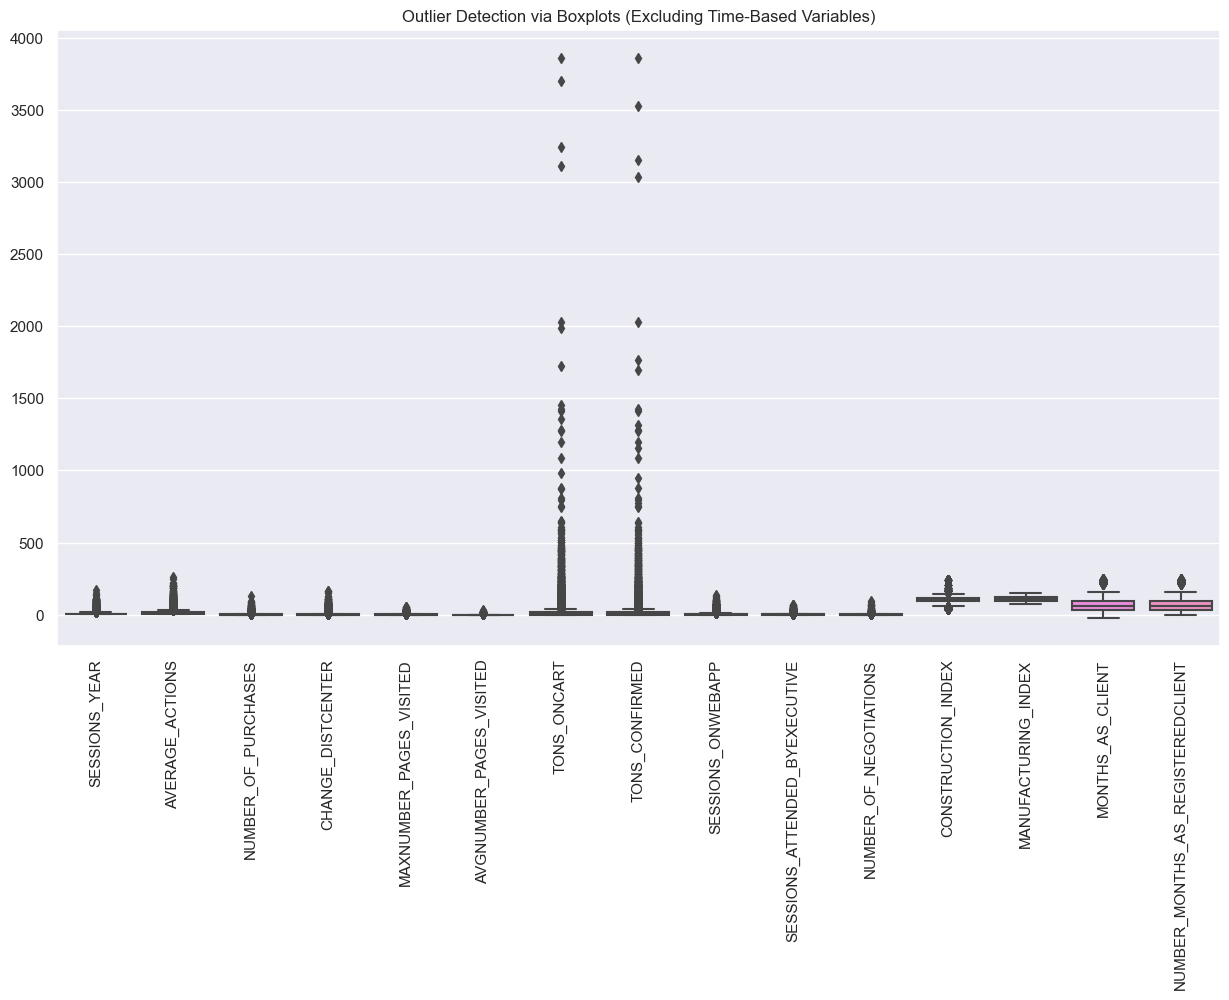

In [5]:
# --- Extract Numeric Columns from the Dataset ---
numeric_data = database.select_dtypes(include=['number'])

# --- Define Numeric Columns (Excluding Time-Based Variables) ---
numeric_cols_excluding_time = [
    col for col in numeric_data.columns if col not in ['MONTH', 'YEAR']
]

# --- Visualize Outliers Using Boxplots ---
plt.figure(figsize=(15, 8))
sns.boxplot(data=database[numeric_cols_excluding_time])

# --- Formatting the Plot ---
plt.xticks(rotation=90)  # Rotate x-axis labels for readability
plt.title("Outlier Detection via Boxplots (Excluding Time-Based Variables)")
plt.show()


#### Correlation Analysis


📊 Correlation Matrix (Numerical Variables):


,SESSIONS_YEAR,AVERAGE_ACTIONS,NUMBER_OF_PURCHASES,CHANGE_DISTCENTER,MAXNUMBER_PAGES_VISITED,AVGNUMBER_PAGES_VISITED,TONS_ONCART,TONS_CONFIRMED,SESSIONS_ONWEBAPP,SESSIONS_ATTENDED_BYEXECUTIVE,NUMBER_OF_NEGOTIATIONS,CONSTRUCTION_INDEX,MANUFACTURING_INDEX,MONTHS_AS_CLIENT,NUMBER_MONTHS_AS_REGISTEREDCLIENT
SESSIONS_YEAR,1.000,-0.018,0.591,0.612,0.263,-0.016,0.390,0.385,0.935,0.460,0.498,-0.066,-0.023,0.201,0.202
AVERAGE_ACTIONS,-0.018,1.000,0.275,0.069,0.267,0.364,0.202,0.202,-0.023,0.007,0.188,-0.185,-0.240,0.033,0.033
NUMBER_OF_PURCHASES,0.591,0.275,1.000,0.455,0.297,0.084,0.584,0.587,0.537,0.309,0.708,-0.195,-0.188,0.168,0.168
CHANGE_DISTCENTER,0.612,0.069,0.455,1.000,0.185,0.003,0.480,0.474,0.488,0.492,0.263,-0.048,-0.001,0.158,0.158
MAXNUMBER_PAGES_VISITED,0.263,0.267,0.297,0.185,1.000,0.742,0.200,0.198,0.265,0.072,0.276,-0.196,-0.233,0.116,0.116
AVGNUMBER_PAGES_VISITED,-0.016,0.364,0.084,0.003,0.742,1.000,0.045,0.045,0.016,-0.087,0.090,-0.150,-0.184,0.040,0.039
TONS_ONCART,0.390,0.202,0.584,0.480,0.200,0.045,1.000,0.997,0.298,0.345,0.410,-0.098,-0.089,0.117,0.117
TONS_CONFIRMED,0.385,0.202,0.587,0.474,0.198,0.045,0.997,1.000,0.295,0.340,0.414,-0.100,-0.091,0.117,0.117
SESSIONS_ONWEBAPP,0.935,-0.023,0.537,0.488,0.265,0.016,0.298,0.295,1.000,0.114,0.496,-0.095,-0.051,0.171,0.172
SESSIONS_ATTENDED_BYEXECUTIVE,0.460,0.007,0.309,0.492,0.072,-0.087,0.345,0.340,0.114,1.000,0.151,0.053,0.064,0.134,0.134


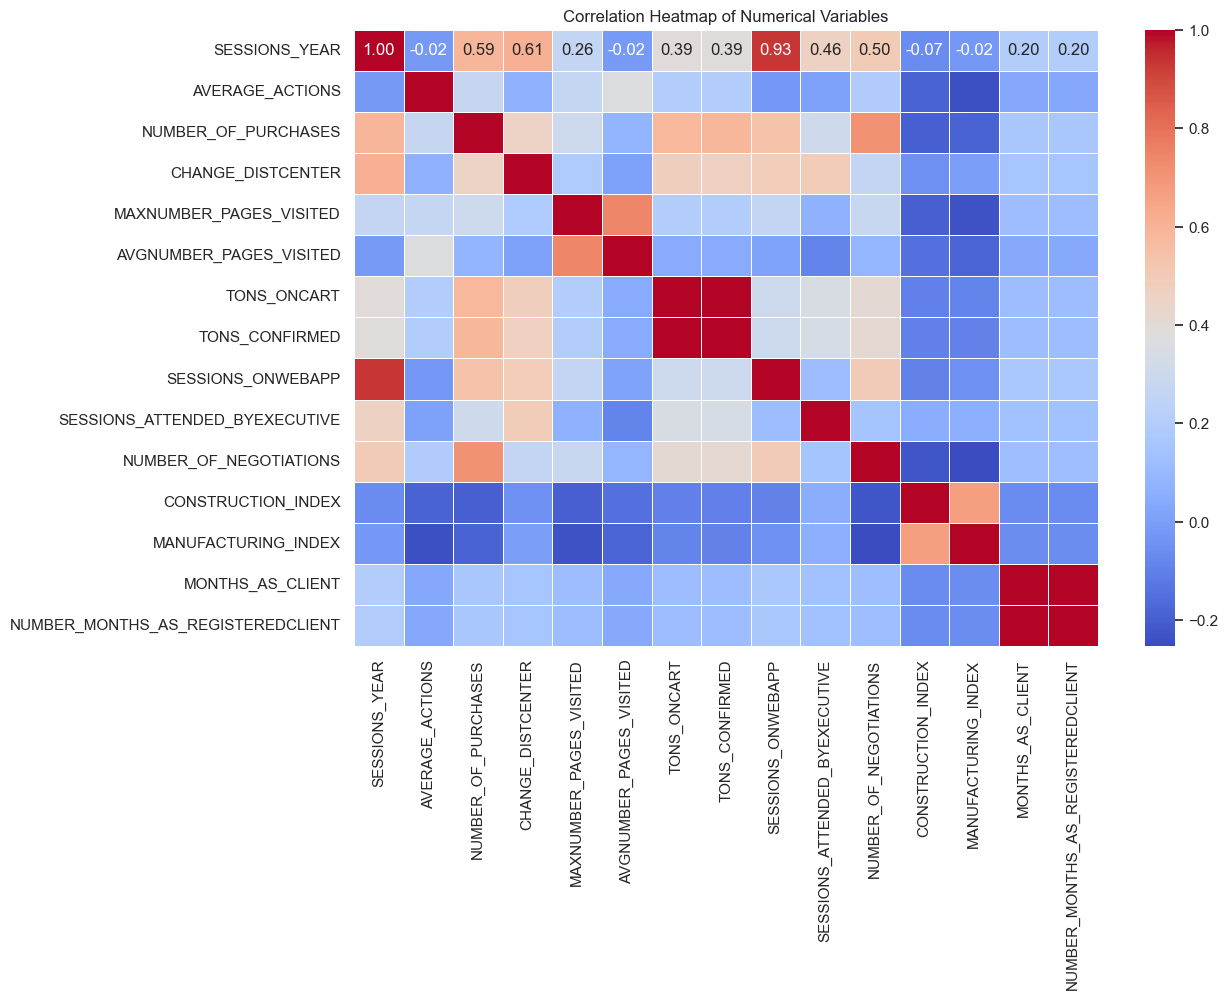

In [6]:
# --- Define Numeric Columns (Excluding Time-Based Variables) ---
numeric_cols_excluding_time = [
    col for col in database.select_dtypes(include=["number"]).columns if col not in ['MONTH', 'YEAR']
]

# --- Compute Correlation Matrix ---
correlation_matrix = database[numeric_cols_excluding_time].corr()

# --- Display Correlation Matrix ---
print("\n📊 Correlation Matrix (Numerical Variables):")
display(correlation_matrix)

# --- Visualize Correlation Matrix Using a Heatmap ---
plt.figure(figsize=(12, 8))  # Set figure size
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

# --- Formatting the Plot ---
plt.title("Correlation Heatmap of Numerical Variables")
plt.xticks(rotation=90)  # Rotate x-axis labels for readability
plt.yticks(rotation=0)  # Keep y-axis labels readable
plt.show()

#### Bivariate Analysis

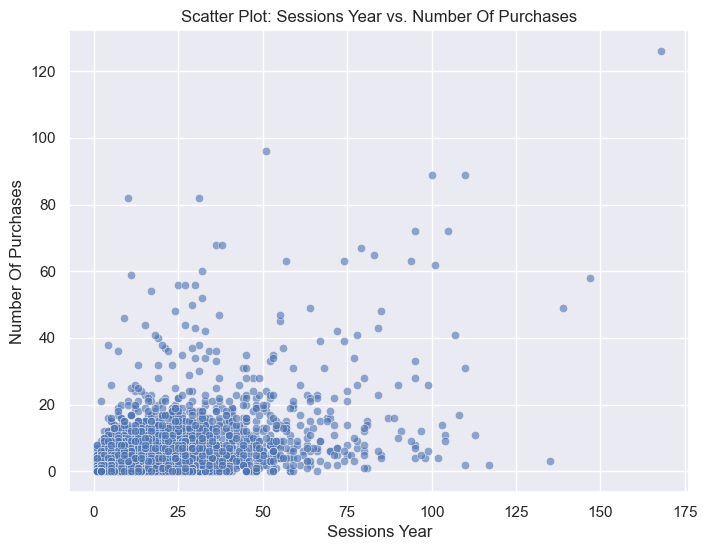

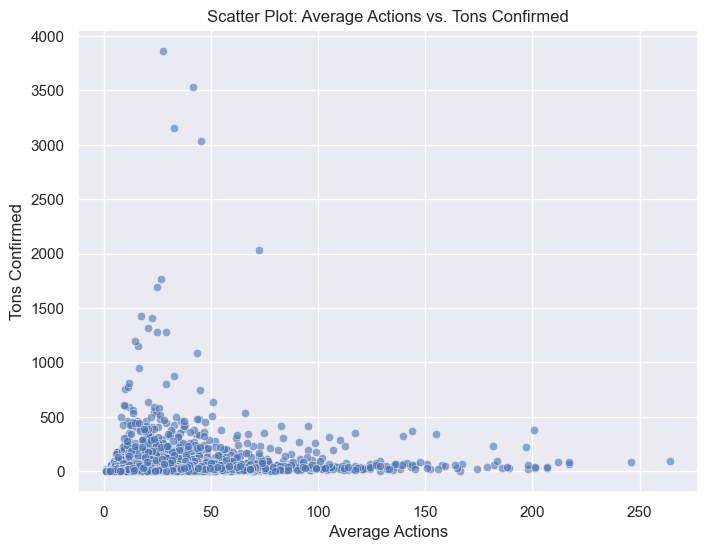

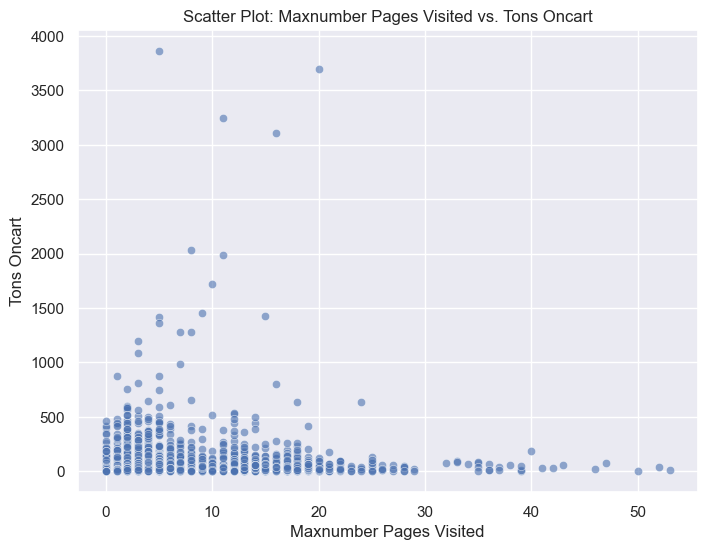

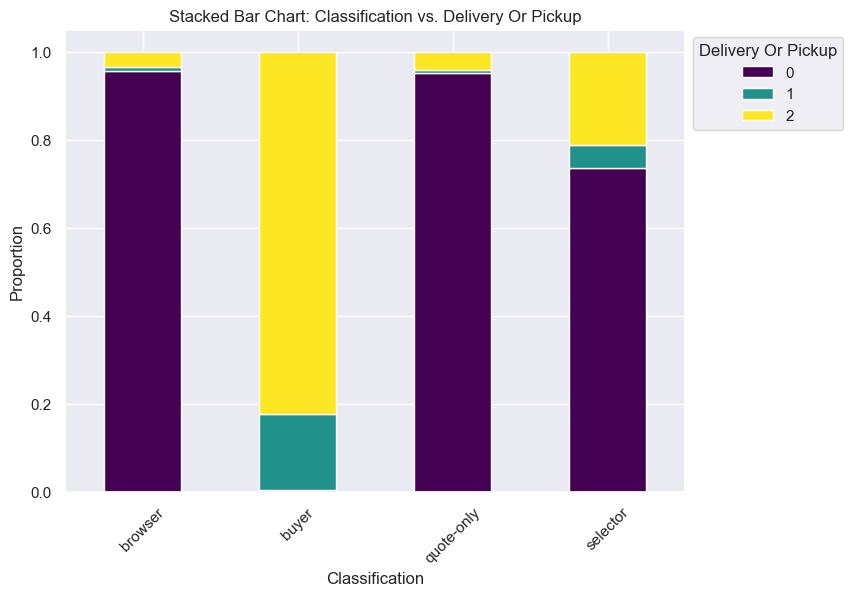

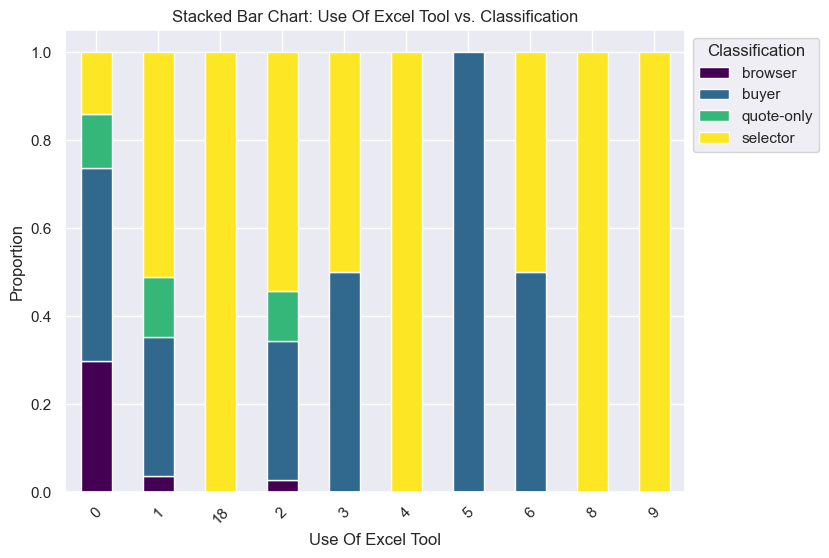

In [7]:
# --- Define Pairs of Continuous Variables to Analyze ---
scatter_pairs = [
    ('SESSIONS_YEAR', 'NUMBER_OF_PURCHASES'),
    ('AVERAGE_ACTIONS', 'TONS_CONFIRMED'),
    ('MAXNUMBER_PAGES_VISITED', 'TONS_ONCART')
]

# --- Create Scatter Plots ---
for x_var, y_var in scatter_pairs:
    plt.figure(figsize=(8, 6))  # Set figure size
    sns.scatterplot(data=database, x=x_var, y=y_var, alpha=0.6)

    # --- Formatting the Plot ---
    plt.title(f"Scatter Plot: {x_var.replace('_', ' ').title()} vs. {y_var.replace('_', ' ').title()}")
    plt.xlabel(x_var.replace("_", " ").title())  # Format labels
    plt.ylabel(y_var.replace("_", " ").title())
    plt.grid(True)  # Add grid for better readability
    plt.show()

# --- Define Categorical Pairs for Analysis ---
categorical_pairs = [
    ('CLASSIFICATION', 'DELIVERY_OR_PICKUP'),
    ('USE_OF_EXCEL_TOOL', 'CLASSIFICATION')
]

# --- Create Cross-Tabulations and Stacked Bar Charts ---
for cat1, cat2 in categorical_pairs:
    crosstab = pd.crosstab(database[cat1], database[cat2], normalize='index')  # Normalize by row
    crosstab.plot(kind='bar', stacked=True, figsize=(8, 6), colormap='viridis')

    # --- Formatting the Plot ---
    plt.title(f"Stacked Bar Chart: {cat1.replace('_', ' ').title()} vs. {cat2.replace('_', ' ').title()}")
    plt.xlabel(cat1.replace("_", " ").title())  # Format labels
    plt.ylabel("Proportion")
    plt.legend(title=cat2.replace("_", " ").title(), bbox_to_anchor=(1, 1))
    plt.xticks(rotation=45)  # Rotate labels for readability
    plt.show()


#### Multivariate Analysis

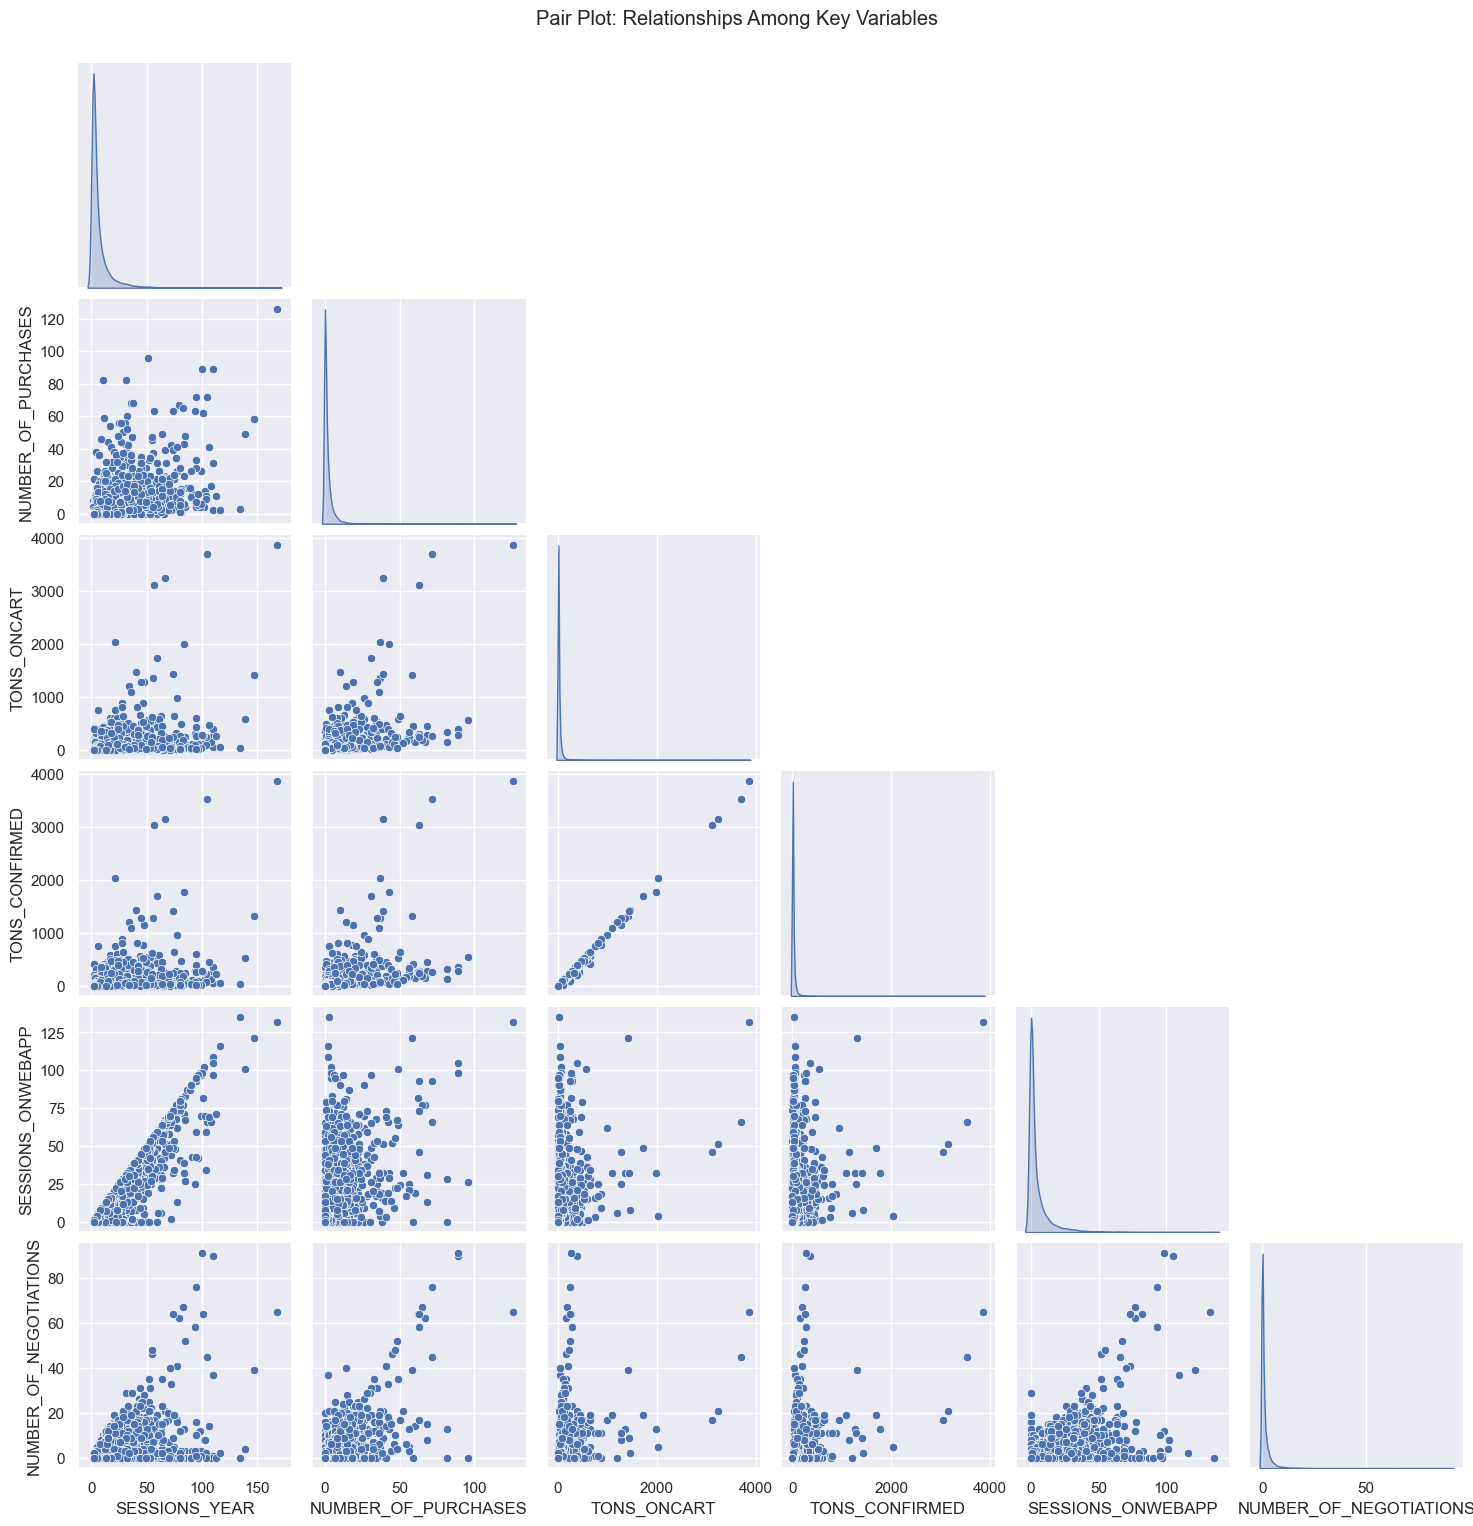

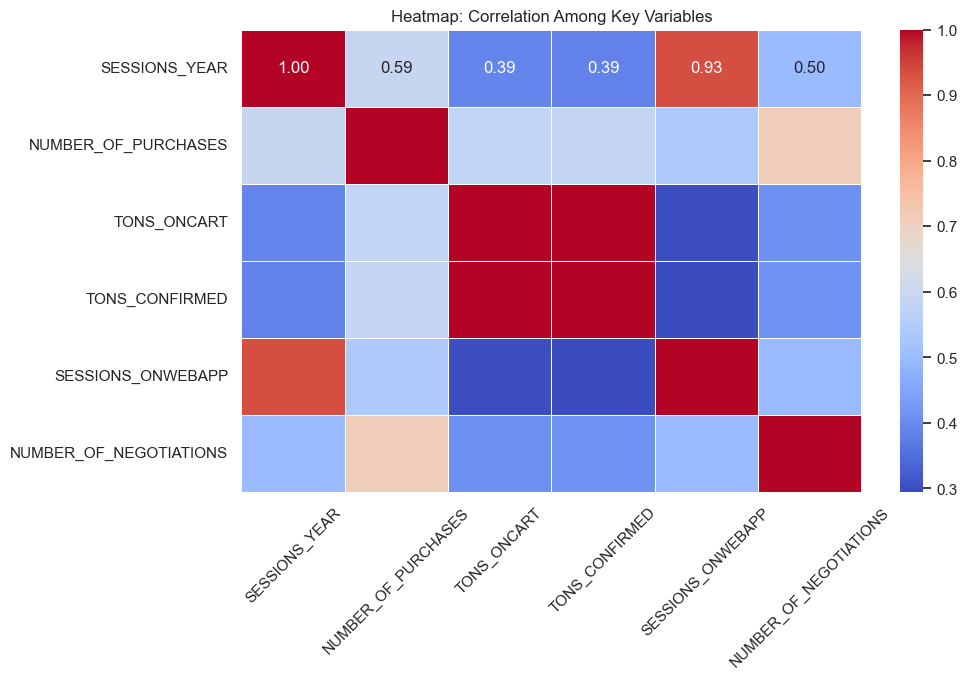

In [8]:
# --- Define Subset of Numeric Variables for Better Clarity ---
pairplot_vars = [
    'SESSIONS_YEAR', 'NUMBER_OF_PURCHASES', 'TONS_ONCART', 
    'TONS_CONFIRMED', 'SESSIONS_ONWEBAPP', 'NUMBER_OF_NEGOTIATIONS'
]

# --- Convert Inf and -Inf to NaN Across the Dataset ---
database.replace([np.inf, -np.inf], np.nan, inplace=True)

# --- Drop Rows Containing NaN to Avoid Errors ---
database_clean = database.dropna(subset=pairplot_vars)

# --- Generate Pair Plot ---
sns.pairplot(database_clean[pairplot_vars], diag_kind='kde', corner=True)

# --- Formatting the Plot ---
plt.suptitle("Pair Plot: Relationships Among Key Variables", y=1.02)
plt.show()

# --- Compute Correlation Matrix for Heatmap ---
correlation_matrix = database_clean[pairplot_vars].corr()

# --- Generate Heatmap ---
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

# --- Formatting the Plot ---
plt.title("Heatmap: Correlation Among Key Variables")
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.yticks(rotation=0)   # Keep y-axis labels readable
plt.show()

#### One-Hot Encoding

In [9]:
# --- Identify Categorical Variables for Encoding ---
categorical_cols = [
    'DELIVERY_OR_PICKUP', 'USE_OF_EXCEL_TOOL', 
    'USE_OF_CLIENT_CATALOGUE', 'USE_OF_PROPOSAL'
]

# --- Convert Categorical Variables to String (Ensures Proper Encoding) ---
for col in categorical_cols:
    database[col] = database[col].astype(str)

# --- Count Unique Values in Each Categorical Column ---
print("\n📊 Unique Values in Categorical Variables (Before Encoding):")
for col in categorical_cols:
    unique_values = database[col].nunique()
    print(f"{col}: {unique_values} unique values")

# --- Perform One-Hot Encoding (Preserve All Categories) ---
database_encoded = pd.get_dummies(database, columns=categorical_cols, drop_first=False)

# --- Display Encoded Column Names ---
print("\n🛠️ Encoded Columns After One-Hot Encoding:")
print([col for col in database_encoded.columns if any(base_col in col for base_col in categorical_cols)])

# --- Display Shape After Encoding ---
print("\n✅ Shape After One-Hot Encoding:", database_encoded.shape)

# --- Validate That Encoding Preserved Original Data ---
print("\n🔍 Data Preview After Encoding:")
display(database_encoded.head())

# --- Check for Multicollinearity Considerations ---
print("\n⚠️ Checking Multicollinearity Risk (Dropping First Column for Each Categorical Variable)")
for col in categorical_cols:
    encoded_cols = [c for c in database_encoded.columns if c.startswith(col+'_')]
    if len(encoded_cols) > 1:
        print(f"Dropping {encoded_cols[0]} to reduce multicollinearity risk.")
        database_encoded.drop(columns=[encoded_cols[0]], inplace=True)

# --- Final Shape After Dropping Redundant Columns ---
print("\n✅ Final Shape After One-Hot Encoding & Multicollinearity Handling:", database_encoded.shape)



📊 Unique Values in Categorical Variables (Before Encoding):
DELIVERY_OR_PICKUP: 3 unique values
USE_OF_EXCEL_TOOL: 10 unique values
USE_OF_CLIENT_CATALOGUE: 5 unique values
USE_OF_PROPOSAL: 2 unique values

🛠️ Encoded Columns After One-Hot Encoding:
['DELIVERY_OR_PICKUP_0', 'DELIVERY_OR_PICKUP_1', 'DELIVERY_OR_PICKUP_2', 'USE_OF_EXCEL_TOOL_0', 'USE_OF_EXCEL_TOOL_1', 'USE_OF_EXCEL_TOOL_18', 'USE_OF_EXCEL_TOOL_2', 'USE_OF_EXCEL_TOOL_3', 'USE_OF_EXCEL_TOOL_4', 'USE_OF_EXCEL_TOOL_5', 'USE_OF_EXCEL_TOOL_6', 'USE_OF_EXCEL_TOOL_8', 'USE_OF_EXCEL_TOOL_9', 'USE_OF_CLIENT_CATALOGUE_0', 'USE_OF_CLIENT_CATALOGUE_1', 'USE_OF_CLIENT_CATALOGUE_2', 'USE_OF_CLIENT_CATALOGUE_3', 'USE_OF_CLIENT_CATALOGUE_4', 'USE_OF_PROPOSAL_0', 'USE_OF_PROPOSAL_1']

✅ Shape After One-Hot Encoding: (17944, 39)

🔍 Data Preview After Encoding:


,ID_CLIENT,SESSIONS_YEAR,AVERAGE_ACTIONS,NUMBER_OF_PURCHASES,CHANGE_DISTCENTER,MAXNUMBER_PAGES_VISITED,AVGNUMBER_PAGES_VISITED,TONS_ONCART,TONS_CONFIRMED,SESSIONS_ONWEBAPP,SESSIONS_ATTENDED_BYEXECUTIVE,NUMBER_OF_NEGOTIATIONS,CONSTRUCTION_INDEX,MANUFACTURING_INDEX,MONTHS_AS_CLIENT,NUMBER_MONTHS_AS_REGISTEREDCLIENT,CLASSIFICATION,MONTH,YEAR,DELIVERY_OR_PICKUP_0,DELIVERY_OR_PICKUP_1,DELIVERY_OR_PICKUP_2,USE_OF_EXCEL_TOOL_0,USE_OF_EXCEL_TOOL_1,USE_OF_EXCEL_TOOL_18,USE_OF_EXCEL_TOOL_2,USE_OF_EXCEL_TOOL_3,USE_OF_EXCEL_TOOL_4,USE_OF_EXCEL_TOOL_5,USE_OF_EXCEL_TOOL_6,USE_OF_EXCEL_TOOL_8,USE_OF_EXCEL_TOOL_9,USE_OF_CLIENT_CATALOGUE_0,USE_OF_CLIENT_CATALOGUE_1,USE_OF_CLIENT_CATALOGUE_2,USE_OF_CLIENT_CATALOGUE_3,USE_OF_CLIENT_CATALOGUE_4,USE_OF_PROPOSAL_0,USE_OF_PROPOSAL_1
0,896397,13,14.538,4,12,7,1,45.390,45.390,6,7,0,107.919,124.311,111,111,buyer,8,2017,False,False,True,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
1,988398,29,11.069,9,18,12,3,57.940,57.940,29,0,7,102.309,118.543,101,101,selector,8,2017,False,False,True,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
2,957974,4,1.250,0,0,2,0,10.710,10.710,4,0,1,115.106,106.574,9,9,selector,8,2017,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
3,951495,1,16.000,0,0,4,4,6.050,6.050,1,0,1,102.840,129.212,38,38,quote-only,8,2017,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
4,136560,3,7.333,0,0,0,0,0.000,0.000,3,0,0,112.763,146.941,25,25,browser,8,2017,True,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False



⚠️ Checking Multicollinearity Risk (Dropping First Column for Each Categorical Variable)
Dropping DELIVERY_OR_PICKUP_0 to reduce multicollinearity risk.
Dropping USE_OF_EXCEL_TOOL_0 to reduce multicollinearity risk.
Dropping USE_OF_CLIENT_CATALOGUE_0 to reduce multicollinearity risk.
Dropping USE_OF_PROPOSAL_0 to reduce multicollinearity risk.

✅ Final Shape After One-Hot Encoding & Multicollinearity Handling: (17944, 35)


### Feature Engineering and Selection

#### New Variables Creation

In [10]:
# --- Create Engagement Score (Combining Session-Based Metrics) ---
database_encoded["ENGAGEMENT_SCORE"] = (
    database_encoded["SESSIONS_YEAR"] * 0.4 + 
    database_encoded["AVERAGE_ACTIONS"] * 0.3 + 
    database_encoded["SESSIONS_ONWEBAPP"] * 0.3
)

# --- Create Purchase Conversion Rate (Purchases per Session) ---
database_encoded["PURCHASE_CONVERSION_RATE"] = (
    database_encoded["NUMBER_OF_PURCHASES"] / database_encoded["SESSIONS_YEAR"]
).replace([np.inf, -np.inf], 0).fillna(0)  # Handle division by zero

# --- Create Cart Confirmation Ratio (Tons Confirmed / Tons Added to Cart) ---
database_encoded["CART_CONFIRMATION_RATIO"] = (
    database_encoded["TONS_CONFIRMED"] / database_encoded["TONS_ONCART"]
).replace([np.inf, -np.inf], 0).fillna(0)  # Handle division by zero

# --- Create Categorical Bucket for Client Tenure (New vs. Long-Term Clients) ---
database_encoded["CLIENT_TENURE_GROUP"] = pd.cut(
    database_encoded["MONTHS_AS_CLIENT"], 
    bins=[0, 12, 36, 60, np.inf], 
    labels=["<1 Year", "1-3 Years", "3-5 Years", "5+ Years"]
)

print("\n✅ New Feature Creation Completed.")


✅ New Feature Creation Completed.


#### Variable Transformation

In [11]:
# --- Log Transform Highly Skewed Variables ---
skewed_cols = ["TONS_ONCART", "TONS_CONFIRMED", "PURCHASE_CONVERSION_RATE"]

for col in skewed_cols:
    if col in database_encoded.columns:
        database_encoded[f"{col}_LOG"] = np.log1p(database_encoded[col])  # log(1 + x) to handle zero values

print("\n✅ Variable Transformation (Log Transform for Skewed Data) Completed.")


✅ Variable Transformation (Log Transform for Skewed Data) Completed.


#### Variable Selection

In [12]:
# --- Select Final Features for Modeling ---
selected_features = [
    "ENGAGEMENT_SCORE", "PURCHASE_CONVERSION_RATE_LOG", "CART_CONFIRMATION_RATIO",
    "NUMBER_OF_PURCHASES", "CHANGE_DISTCENTER", "MAXNUMBER_PAGES_VISITED",
    "SESSIONS_ATTENDED_BYEXECUTIVE", "NUMBER_OF_NEGOTIATIONS", "CLIENT_TENURE_GROUP"
]

# --- Ensure selected features exist in dataset ---
database_final = database_encoded[selected_features]

print("\n✅ Feature Selection Completed. Shape of Final Dataset:", database_final.shape)



✅ Feature Selection Completed. Shape of Final Dataset: (17944, 9)


### Preliminary Findings / Exploratory Data Analysis (EDA) Summary

A comprehensive analysis of Alpha Steel’s digital sales dataset was conducted to uncover patterns in client engagement, purchasing behavior, and factors influencing conversion rates. The findings from univariate, bivariate, and multivariate analyses informed key decisions regarding feature engineering and selection for further modeling.

#### Univariate Analysis Findings
Examining individual variables revealed significant variations in engagement and purchasing behaviors:
- Sessions and actions per client varied widely, indicating diverse levels of interaction with the platform.
- Tons added to the cart (`TONS_ONCART`) and tons confirmed (`TONS_CONFIRMED`) were highly skewed, necessitating transformation to normalize their distribution.

#### Bivariate Analysis Findings
Exploring relationships between two variables provided insights into client decision-making:
- Number of purchases (`NUMBER_OF_PURCHASES`) showed a strong positive correlation with both annual session frequency (`SESSIONS_YEAR`) and price negotiations (`NUMBER_OF_NEGOTIATIONS`), indicating that engaged and price-sensitive clients are more likely to convert.
- Cart confirmation ratio (`CART_CONFIRMATION_RATIO`) highlighted differences in buyer intent, distinguishing users who explore options versus those who proceed with transactions.

#### Multivariate Analysis Findings
Evaluating multiple variables together helped identify deeper behavioral trends:
- A heatmap visualization confirmed that engagement metrics, session activity, and negotiation behavior are strong predictors of purchasing likelihood.
- Client tenure segmentation (`CLIENT_TENURE_GROUP`) suggested that long-term clients are more likely to make repeat purchases, reinforcing the importance of customer retention strategies.

#### Feature Selection and Next Steps
Based on these insights, nine key features were selected for modeling, emphasizing statistical significance and business relevance. These features will serve as inputs for machine learning models aimed at optimizing client engagement and improving conversion rates.

With a refined dataset, the next steps involve scaling features, selecting modeling techniques, and evaluating predictive performance to further enhance Alpha Steel’s digital sales strategy.

### Understanding Centering and Scaling

#### To center and scale or not?

As part of the data preprocessing strategy for Alpha Steel’s digital sales dataset, we must determine whether centering and scaling are necessary to optimize machine learning performance. Differences in numerical scales across features can impact certain algorithms, while others remain unaffected. To ensure that model training is efficient and interpretable, we evaluate the role of feature scaling in this dataset.

#### When Scaling is Required
Certain machine learning algorithms rely on distance-based calculations or iterative optimization techniques, making them highly sensitive to feature scales. These include:  
- Gradient Descent-Based Models** (*e.g., Logistic Regression, SVM, KNN, Neural Networks*)  
  - Why? Features with larger magnitudes can dominate smaller-scale features, affecting model convergence and performance.  
- Distance-Based Models (*e.g., K-Means, KNN, PCA, SVM, LDA*)  
  - Why? These models measure similarity using Euclidean or other distance metrics, which can be distorted if features have vastly different scales.

#### When Scaling is Not Necessary
Not all machine learning models require feature scaling. Decision tree-based algorithms, which determine splits based on feature values rather than distance metrics, are naturally invariant to scale differences. These include:  
- Tree-Based Models (*e.g., Decision Trees, Random Forest, XGBoost*)  
  - Why? These models do not compute distances between data points, so scaling has no impact on their ability to learn meaningful patterns.

#### Key Insights from the Dataset  
- **Engagement Metrics** (*e.g., `SESSIONS_YEAR`, `SESSIONS_ONWEBAPP`, `AVERAGE_ACTIONS`*) exhibit significant numerical variations, making scaling necessary for certain models.  
- **Financial and Volume-Based Metrics** (*e.g., `TONS_ONCART`, `TONS_CONFIRMED`, `NUMBER_OF_PURCHASES`*) show highly skewed distributions, which may require log transformation before scaling.  
- **Categorical Variables** (*e.g., one-hot encoded features like `DELIVERY_OR_PICKUP`, `USE_OF_EXCEL_TOOL`*) do **not** require scaling, as they are already binary (0/1).  

### Final Decision: Scaling Strategy
Standardization (Z-score scaling) will be applied to continuous numerical variables for models that rely on distance-based calculations.  
Tree-based models will use raw data, as they are unaffected by feature scale differences.  

By applying targeted scaling where necessary, we ensure that model performance is optimized without introducing unnecessary transformations. Moving forward, scaling techniques will be evaluated alongside model selection to determine the most effective preprocessing approach.

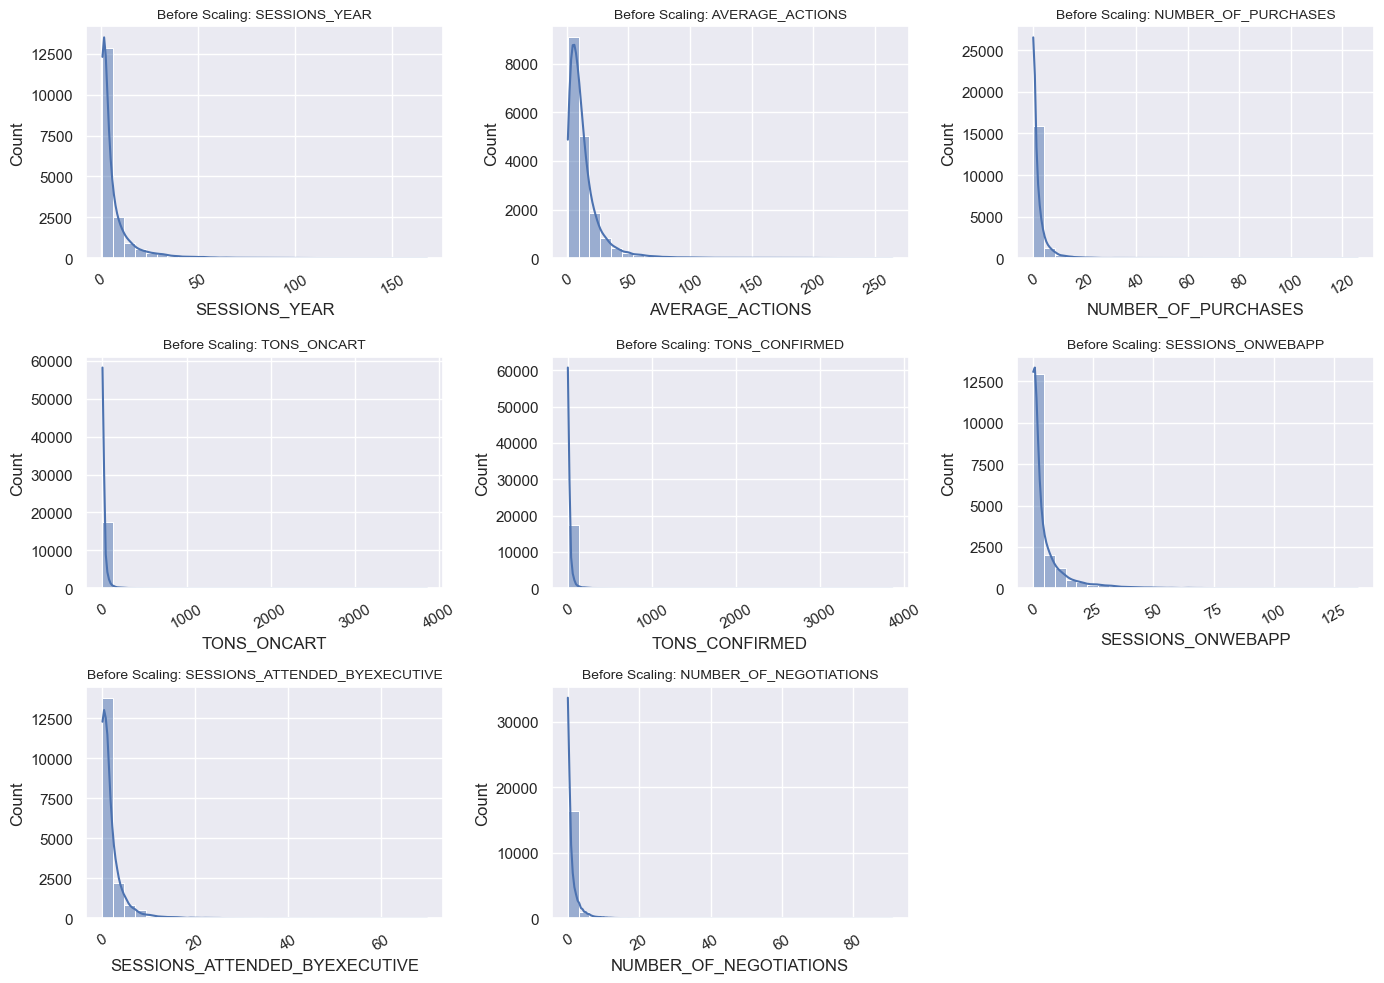

In [13]:
# --- Before Scaling: Check Distributions ---
# --- Select Numerical Variables for Scaling ---
numeric_features = [
    "SESSIONS_YEAR", "AVERAGE_ACTIONS", "NUMBER_OF_PURCHASES",
    "TONS_ONCART", "TONS_CONFIRMED", "SESSIONS_ONWEBAPP",
    "SESSIONS_ATTENDED_BYEXECUTIVE", "NUMBER_OF_NEGOTIATIONS"
]

# --- Adjust Figure Size & Layout ---
plt.figure(figsize=(14, 10))  # Increase figure size

for i, col in enumerate(numeric_features):
    plt.subplot(3, 3, i + 1)  # Use 3x3 grid for better spacing
    sns.histplot(database_encoded[col], bins=30, kde=True)
    plt.title(f"Before Scaling: {col}", fontsize=10)  # Adjust title size
    plt.xticks(rotation=30)  # Rotate x-axis labels slightly for readability

plt.tight_layout()  # Prevent label overlap
plt.show()

In [14]:
# --- Apply Scaling to Numerical Variables ---
database_scaled = database_encoded.copy()
database_scaled[numeric_features] = scaler.fit_transform(database_scaled[numeric_features])

print("\n✅ Scaling Applied: Features Standardized (Mean = 0, Variance = 1)")


✅ Scaling Applied: Features Standardized (Mean = 0, Variance = 1)


#### Before-and-After Comparison

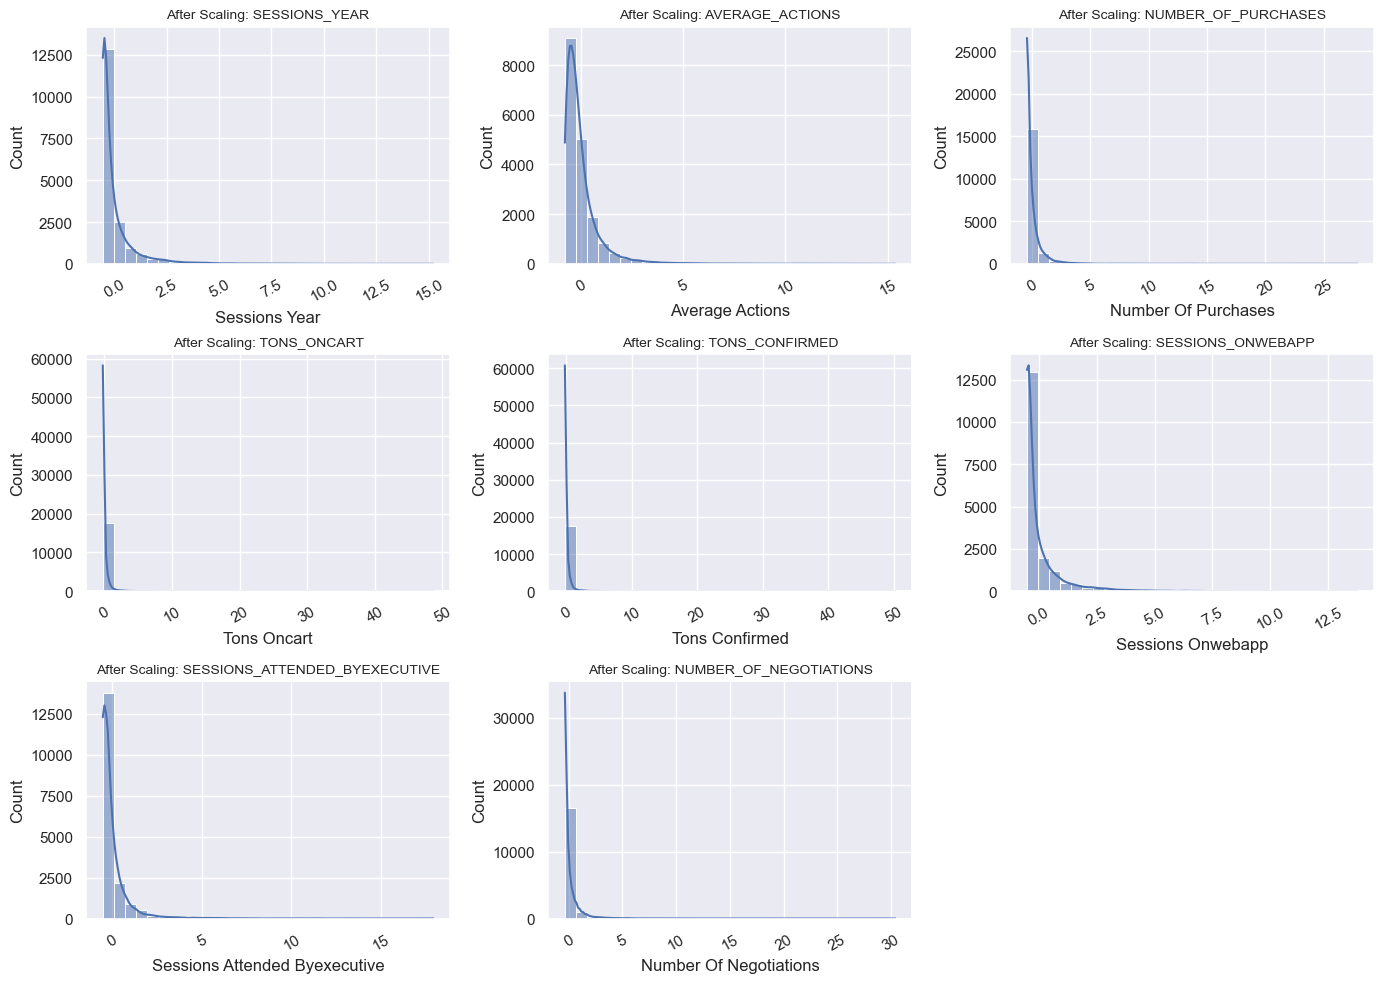

In [15]:
# --- Visualize Distributions After Scaling ---
plt.figure(figsize=(14, 10))  # Increase figure size for better spacing

for i, col in enumerate(numeric_features):
    plt.subplot(3, 3, i + 1)  # Use a 3x3 grid layout for better spacing
    sns.histplot(database_scaled[col], bins=30, kde=True)

    # --- Formatting the Plot ---
    plt.title(f"After Scaling: {col}", fontsize=10)  # Adjust title size
    plt.xticks(rotation=30)  # Rotate x-axis labels slightly for readability
    plt.xlabel(col.replace("_", " ").title())  # Improve label formatting

plt.tight_layout()  # Automatically adjust spacing to prevent overlap
plt.show()

#  Building Predictive Model

### Prepare the Dataset

In [16]:
# --- Define Target (y) and Predictors (X) ---
X = database_encoded.drop(columns=['CLASSIFICATION'])  # Drop target variable from predictors
y = database_encoded['CLASSIFICATION']  # Define target variable

# --- Display Unique Classes in Target ---
print("🔹 Unique Classes in Target Variable:", y.unique())

🔹 Unique Classes in Target Variable: ['buyer', 'selector', 'quote-only', 'browser']
Categories (4, object): ['browser', 'buyer', 'quote-only', 'selector']


In [17]:
# --- Split Data into Training and Testing Sets ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # Stratify to maintain class distribution
)

# --- Display Dataset Shapes ---
print(f"✅ Training Set Shape: {X_train.shape}")
print(f"✅ Testing Set Shape: {X_test.shape}")

✅ Training Set Shape: (14355, 41)
✅ Testing Set Shape: (3589, 41)


In [18]:
# --- Dynamically Select All Encoded Variants of DELIVERY_OR_PICKUP ---
delivery_pickup_features = [col for col in X_train.columns if col.startswith("DELIVERY_OR_PICKUP")]

# --- Define Final Feature Set Dynamically ---
selected_features = [
    "SESSIONS_YEAR", "SESSIONS_ONWEBAPP", "AVERAGE_ACTIONS",
    "NUMBER_OF_PURCHASES", "NUMBER_OF_NEGOTIATIONS",
    "TONS_ONCART", "TONS_CONFIRMED",
    "MONTHS_AS_CLIENT"
] + delivery_pickup_features  # Add all encoded DELIVERY_OR_PICKUP columns dynamically

# --- Filter Dataset to Include Only Selected Features ---
X_train = X_train[selected_features]
X_test = X_test[selected_features]

# --- Display Final Feature Set ---
print(f"✅ Final Feature Set: {X_train.columns.tolist()}")

✅ Final Feature Set: ['SESSIONS_YEAR', 'SESSIONS_ONWEBAPP', 'AVERAGE_ACTIONS', 'NUMBER_OF_PURCHASES', 'NUMBER_OF_NEGOTIATIONS', 'TONS_ONCART', 'TONS_CONFIRMED', 'MONTHS_AS_CLIENT', 'DELIVERY_OR_PICKUP_1', 'DELIVERY_OR_PICKUP_2']


### Build Parametric Models

##### Standard Logistic Regression

In [19]:
# --- Scale the Data ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Apply SMOTE to Balance Classes ---
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

# --- Display Class Distribution After SMOTE ---
print("\n📊 Class Distribution After SMOTE Oversampling:")
print(Counter(y_train_balanced))  # Verifies balancing

# --- Train Logistic Regression Model with Class Weights ---
logreg = LogisticRegression(
    max_iter=2000,  # Increased iterations to ensure convergence
    solver='lbfgs',  # Recommended solver for multinomial classification
    multi_class='multinomial',
    class_weight='balanced'  # Adjusts weights based on class distribution
)

logreg.fit(X_train_balanced, y_train_balanced)
y_pred_log = logreg.predict(X_test_scaled)

# --- Evaluate Model Performance ---
print("\n📊 Logistic Regression Performance (With Balancing):")
print(f"✅ Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(classification_report(y_test, y_pred_log))


📊 Class Distribution After SMOTE Oversampling:
Counter({'buyer': 6258, 'selector': 6258, 'browser': 6258, 'quote-only': 6258})

📊 Logistic Regression Performance (With Balancing):
✅ Accuracy: 0.7637
              precision    recall  f1-score   support

     browser       0.74      0.81      0.77      1056
       buyer       0.92      0.95      0.94      1565
  quote-only       0.55      0.78      0.64       440
    selector       0.26      0.09      0.14       528

    accuracy                           0.76      3589
   macro avg       0.62      0.66      0.62      3589
weighted avg       0.72      0.76      0.74      3589



##### Logistic Regression with LASSO

In [20]:
# --- Train Logistic Regression with LASSO ---
logreg_lasso = LogisticRegression(
    penalty='l1',  # LASSO Regularization
    solver='saga',  # Required solver for L1
    max_iter=10000,  # Higher iterations for convergence
    tol=1e-5,  # Lower tolerance for better optimization
    class_weight='balanced',  # Handles class imbalance
    multi_class='multinomial',
    C=0.1  # Lower C increases regularization strength
)

logreg_lasso.fit(X_train_scaled, y_train)
y_pred_log_lasso = logreg_lasso.predict(X_test_scaled)

# --- Evaluate LASSO Model Performance ---
print("\n📊 Logistic Regression with LASSO Performance:")
print(f"✅ Accuracy: {accuracy_score(y_test, y_pred_log_lasso):.4f}")
print(classification_report(y_test, y_pred_log_lasso))


📊 Logistic Regression with LASSO Performance:
✅ Accuracy: 0.7651
              precision    recall  f1-score   support

     browser       0.74      0.81      0.77      1056
       buyer       0.91      0.96      0.94      1565
  quote-only       0.54      0.78      0.64       440
    selector       0.28      0.07      0.11       528

    accuracy                           0.77      3589
   macro avg       0.62      0.66      0.62      3589
weighted avg       0.72      0.77      0.73      3589



### NON-PARAMETRIC MODELS

#### Tree-Based Models

##### Random Forest Classifier

In [21]:
# 1️⃣ Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_clf.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_clf.predict(X_test)

# Evaluate Performance
print("\n🌲 Random Forest Performance:")
print(f"✅ Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))


🌲 Random Forest Performance:
✅ Accuracy: 0.8013
              precision    recall  f1-score   support

     browser       0.76      0.79      0.78      1056
       buyer       0.90      0.99      0.94      1565
  quote-only       0.82      0.82      0.82       440
    selector       0.40      0.26      0.31       528

    accuracy                           0.80      3589
   macro avg       0.72      0.71      0.71      3589
weighted avg       0.78      0.80      0.79      3589



##### Gradient Boosting Classifier

In [22]:
# 2️⃣ Gradient Boosting Classifier
gb_clf = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_clf.fit(X_train, y_train)

# Make predictions
y_pred_gb = gb_clf.predict(X_test)

# Evaluate Performance
print("\n🚀 Gradient Boosting Performance:")
print(f"✅ Accuracy: {accuracy_score(y_test, y_pred_gb):.4f}")
print(classification_report(y_test, y_pred_gb))


🚀 Gradient Boosting Performance:
✅ Accuracy: 0.8139
              precision    recall  f1-score   support

     browser       0.73      0.89      0.80      1056
       buyer       0.90      0.99      0.94      1565
  quote-only       0.88      0.81      0.84       440
    selector       0.41      0.14      0.21       528

    accuracy                           0.81      3589
   macro avg       0.73      0.71      0.70      3589
weighted avg       0.78      0.81      0.78      3589



#### Support Vector Machine Classifier with Various Kernels

##### SVM with linear kernel

In [23]:
# Standardize Features (SVM is sensitive to feature scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3️⃣ SVM (Linear Kernel)
svc_linear = SVC(kernel='linear', random_state=42, class_weight='balanced')
svc_linear.fit(X_train_scaled, y_train)

# Predict & Evaluate
y_pred_svc_linear = svc_linear.predict(X_test_scaled)

print("\n⚖️ SVM (Linear Kernel) Performance:")
print(f"✅ Accuracy: {accuracy_score(y_test, y_pred_svc_linear):.4f}")
print(classification_report(y_test, y_pred_svc_linear))


⚖️ SVM (Linear Kernel) Performance:
✅ Accuracy: 0.7765
              precision    recall  f1-score   support

     browser       0.73      0.83      0.77      1056
       buyer       0.89      1.00      0.94      1565
  quote-only       0.63      0.66      0.65       440
    selector       0.38      0.11      0.17       528

    accuracy                           0.78      3589
   macro avg       0.65      0.65      0.63      3589
weighted avg       0.73      0.78      0.74      3589



##### SVM with polynomial kernel

In [24]:
# --- Hyperparameter Optimization: SVM (Polynomial Kernel) ---
# Define parameter space
param_dist = {
    'degree': [2, 3],  # Limit polynomial degree to avoid overfitting
    'C': np.logspace(0, 3, 4),  # Test regularization strength
    'gamma': ['scale']
}

# Use RandomizedSearchCV for faster optimization
random_search = RandomizedSearchCV(
    SVC(kernel='poly', probability=False, random_state=42, class_weight='balanced'),
    param_distributions=param_dist,
    n_iter=5,  # Try 5 random combinations
    cv=3,  # Reduce folds to 3 for speed
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

# Fit the model
random_search.fit(X_train, y_train)

# Get best parameters
print("\n🔍 Best Parameters for SVM (Polynomial Kernel):", random_search.best_params_)

# Evaluate best model
best_svc_poly = random_search.best_estimator_
y_pred_best_svc_poly = best_svc_poly.predict(X_test)

print("\n📊 SVM (Polynomial Kernel) Performance:")
print(f"✅ Accuracy: {accuracy_score(y_test, y_pred_best_svc_poly):.4f}")
print(classification_report(y_test, y_pred_best_svc_poly))

Fitting 3 folds for each of 5 candidates, totalling 15 fits

🔍 Best Parameters for SVM (Polynomial Kernel): {'gamma': 'scale', 'degree': 2, 'C': 100.0}

📊 SVM (Polynomial Kernel) Performance:
✅ Accuracy: 0.6762
              precision    recall  f1-score   support

     browser       0.63      0.87      0.73      1056
       buyer       0.93      0.77      0.84      1565
  quote-only       0.66      0.46      0.54       440
    selector       0.20      0.21      0.20       528

    accuracy                           0.68      3589
   macro avg       0.61      0.57      0.58      3589
weighted avg       0.70      0.68      0.68      3589



##### SVM with RBF kernel

In [25]:
# --- Train & Evaluate SVM (RBF Kernel) ---
svc_rbf = SVC(kernel='rbf', C=1, gamma='scale', probability=True, random_state=42, class_weight='balanced')
svc_rbf.fit(X_train_scaled, y_train)

# Predict & Evaluate
y_pred_svc_rbf = svc_rbf.predict(X_test_scaled)

print("\n🌐 SVM (RBF Kernel) Performance:")
print(f"✅ Accuracy: {accuracy_score(y_test, y_pred_svc_rbf):.4f}")
print(classification_report(y_test, y_pred_svc_rbf))


🌐 SVM (RBF Kernel) Performance:
✅ Accuracy: 0.7738
              precision    recall  f1-score   support

     browser       0.76      0.76      0.76      1056
       buyer       0.90      0.98      0.94      1565
  quote-only       0.64      0.75      0.69       440
    selector       0.36      0.23      0.28       528

    accuracy                           0.77      3589
   macro avg       0.67      0.68      0.67      3589
weighted avg       0.75      0.77      0.76      3589



#### Deep Learning Model

In [26]:
# --- Encode Target Variable (y) ---
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)  
y_test_encoded = label_encoder.transform(y_test)

# --- Convert Target Variable to One-Hot Encoding ---
num_classes = len(label_encoder.classes_)  # Number of unique categories
y_train_one_hot = to_categorical(y_train_encoded, num_classes=num_classes)
y_test_one_hot = to_categorical(y_test_encoded, num_classes=num_classes)

# --- Verify One-Hot Encoding ---
print("\n✅ Target Variable One-Hot Encoding Example:")
print(y_train_one_hot[:5])  # Show first few rows to verify
print(f"\n✅ Shapes After One-Hot Encoding: y_train: {y_train_one_hot.shape}, y_test: {y_test_one_hot.shape}")


✅ Target Variable One-Hot Encoding Example:
[[0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]]

✅ Shapes After One-Hot Encoding: y_train: (14355, 4), y_test: (3589, 4)


In [27]:
# --- Compute Class Weights ---
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_encoded),
    y=y_train_encoded
)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights)}

# --- Define Optimized Deep Learning Model ---
model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),  # Input Layer
    Dense(X_train_scaled.shape[1] * 2, activation='relu'),  # Hidden Layer 1
    Dense(X_train_scaled.shape[1], activation='relu'),  # Hidden Layer 2 (New)
    Dense(num_classes, activation='softmax')  # Output Layer
])

# --- Compile Model with Lower Learning Rate ---
model.compile(
    optimizer=Adam(learning_rate=0.0005),  # Lower learning rate
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# --- Early Stopping Callback ---
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,  # Stop if no improvement after 5 epochs
    restore_best_weights=True
)

# --- Train Model ---
history = model.fit(
    X_train_scaled, y_train_one_hot,
    epochs=50,  # More epochs for better learning
    batch_size=32,
    validation_data=(X_test_scaled, y_test_one_hot),
    class_weight=class_weight_dict,  # Apply class balancing
    callbacks=[early_stopping]  # Prevent overfitting
)

# --- Evaluate Model ---
y_pred_dl = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred_dl, axis=1)

print("\n🤖 **Updated Deep Learning Model Performance:**")
print(f"✅ Accuracy: {accuracy_score(y_test_encoded, y_pred_classes):.4f}")
print(classification_report(y_test_encoded, y_pred_classes))

Epoch 1/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.3838 - loss: 1.3289 - val_accuracy: 0.6796 - val_loss: 0.9620
Epoch 2/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7209 - loss: 0.9953 - val_accuracy: 0.7556 - val_loss: 0.7271
Epoch 3/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7566 - loss: 0.8544 - val_accuracy: 0.7587 - val_loss: 0.6733
Epoch 4/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7544 - loss: 0.8375 - val_accuracy: 0.7618 - val_loss: 0.6641
Epoch 5/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7560 - loss: 0.8153 - val_accuracy: 0.7595 - val_loss: 0.6452
Epoch 6/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7567 - loss: 0.7869 - val_accuracy: 0.7668 - val_loss: 0.6300
Epoch 7/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7522 - loss: 0.8097 - val_accuracy: 0.7646 - val_loss: 0.6406
Epoch 8/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7563 - loss: 0.7898 - val_accuracy: 0.

### Dimensionality Reduction

In [28]:
# --- Standardize Data ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)  # Scale training data for PCA and Clustering

#### Principal Component Analysis PCA (OPTIONAL)

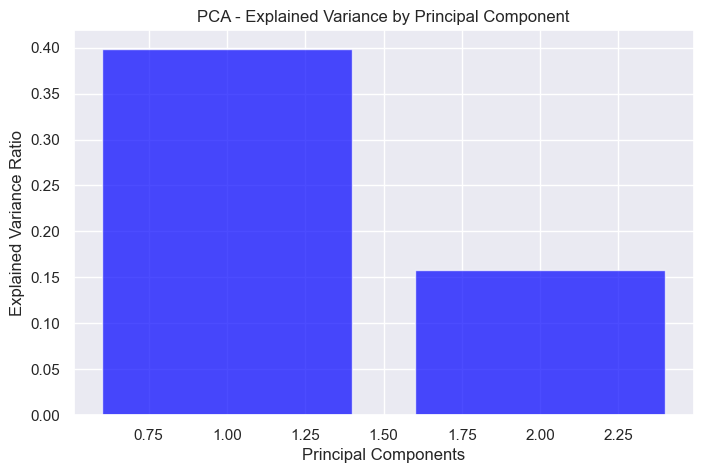

,PC1,PC2
0,0.649,1.382
1,-0.576,1.339
2,0.715,1.207
3,4.170,1.260
4,1.458,0.813


In [29]:
# --- Handle Missing Values ---
imputer = SimpleImputer(strategy="mean")  # Replace NaNs with column mean
X_scaled_imputed = imputer.fit_transform(X_scaled)  # Apply imputation

# --- Perform PCA Function ---
def perform_pca(X, n_components=2):
    """
    Perform PCA on the dataset and return transformed data.
    """
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)  # Ensure X is imputed
    
    # Explained variance ratio
    explained_variance = pca.explained_variance_ratio_
    
    # Visualizing the explained variance
    plt.figure(figsize=(8, 5))
    plt.bar(range(1, n_components+1), explained_variance, alpha=0.7, color='blue')
    plt.xlabel('Principal Components')
    plt.ylabel('Explained Variance Ratio')
    plt.title('PCA - Explained Variance by Principal Component')
    plt.show()
    
    return X_pca, pca

# Apply PCA on the imputed dataset
X_pca, pca_model = perform_pca(X_scaled_imputed)  # Use X_scaled_imputed

# Convert PCA results into a DataFrame
pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
display(pca_df.head())

#### Cluster Analysis (OPTIONAL)

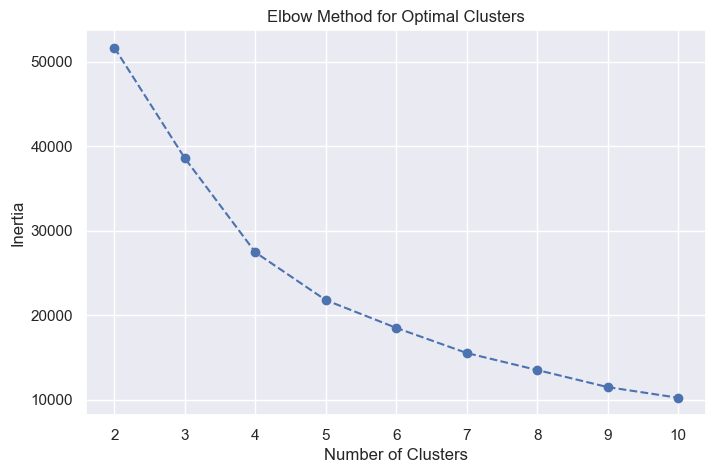

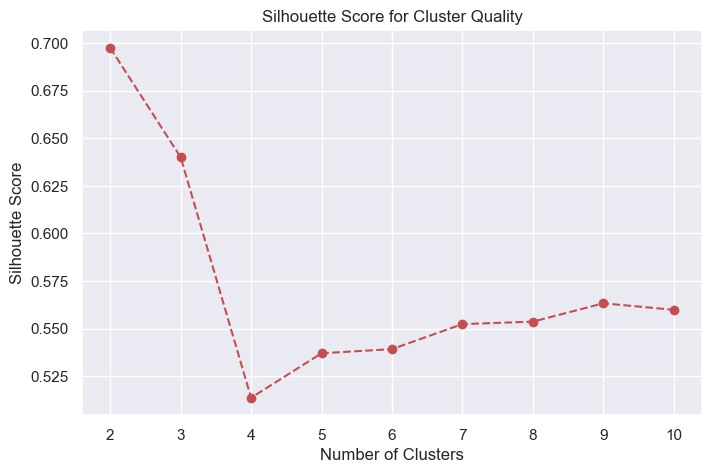


✅ Optimal Number of Clusters: 2


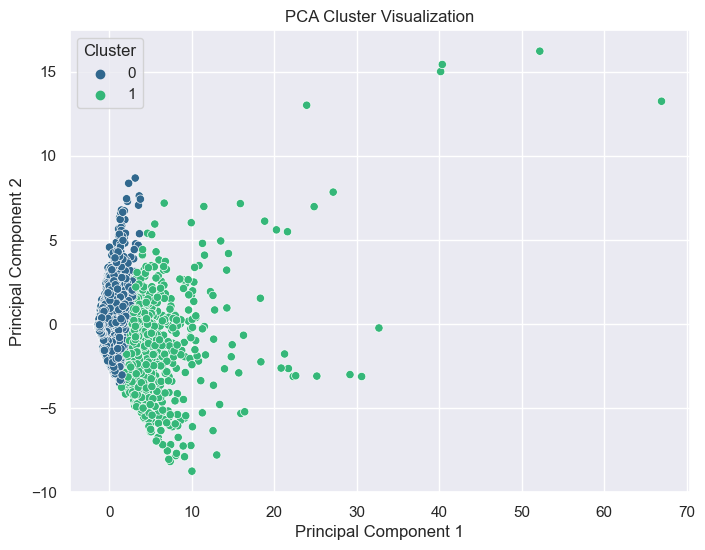

,SESSIONS_YEAR,SESSIONS_ONWEBAPP,AVERAGE_ACTIONS,NUMBER_OF_PURCHASES,NUMBER_OF_NEGOTIATIONS,TONS_ONCART,TONS_CONFIRMED,MONTHS_AS_CLIENT,DELIVERY_OR_PICKUP_1,DELIVERY_OR_PICKUP_2,Cluster
4151,6,0,22.667,5,5,18.350,18.350,13,False,True,1.000
10927,1,0,25.000,1,0,1.610,1.610,44,False,True,0.000
14085,7,2,23.143,6,3,20.390,20.390,38,False,True,0.000
10695,19,14,26.895,15,0,213.070,204.360,123,False,True,0.000
1068,9,9,18.000,6,7,20.830,20.830,20,False,True,0.000


In [30]:
def perform_kmeans(X, max_clusters=10):
    """
    Perform KMeans clustering and determine the optimal number of clusters.
    """
    inertia = []
    silhouette_scores = []
    
    # Try different cluster numbers and store inertia & silhouette scores
    for k in range(2, max_clusters+1):
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(X)
        inertia.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(X, labels))

    # Plot Inertia (Elbow Method)
    plt.figure(figsize=(8, 5))
    plt.plot(range(2, max_clusters+1), inertia, marker='o', linestyle='--', color='b')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Inertia')
    plt.title('Elbow Method for Optimal Clusters')
    plt.show()

    # Plot Silhouette Scores
    plt.figure(figsize=(8, 5))
    plt.plot(range(2, max_clusters+1), silhouette_scores, marker='o', linestyle='--', color='r')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Silhouette Score')
    plt.title('Silhouette Score for Cluster Quality')
    plt.show()

    return inertia, silhouette_scores

# Run KMeans Analysis
inertia, silhouette_scores = perform_kmeans(X_pca)

# Choose the best cluster number from the elbow method and silhouette score
optimal_clusters = np.argmax(silhouette_scores) + 2
print(f"\n✅ Optimal Number of Clusters: {optimal_clusters}")

# --- Final KMeans Clustering with Optimal Clusters ---
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10)
pca_df['Cluster'] = kmeans.fit_predict(X_pca)

# Visualize Clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(x=pca_df['PC1'], y=pca_df['PC2'], hue=pca_df['Cluster'], palette="viridis")
plt.title('PCA Cluster Visualization')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title="Cluster")
plt.show()

# --- Add Cluster Feature to Original Dataset ---
X_train['Cluster'] = pca_df['Cluster']
display(X_train.head())

### Model Training and Optimization

#### K-Fold Cross Validation

In [31]:
# --- Ensure X_train and X_test have the same features ---
missing_cols = set(X_train.columns) - set(X_test.columns)
extra_cols = set(X_test.columns) - set(X_train.columns)

# Align columns by adding missing ones as NaN (if needed)
for col in missing_cols:
    X_test[col] = np.nan  # Add missing columns with NaN values

for col in extra_cols:
    X_train[col] = np.nan  # Add missing columns with NaN values

# Reorder columns to match
X_test = X_test[X_train.columns]  

# --- Handle Missing Values ---
imputer = SimpleImputer(strategy="mean")  # Replace NaNs with column mean
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)  # Apply imputation
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)  # Ensure feature names are retained

# --- Initialize K-Fold Cross-Validation ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# --- Random Forest Model with K-Fold CV ---
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_cv_scores = cross_val_score(rf_model, X_train_imputed, y_train, cv=kf, scoring='accuracy')

# --- Gradient Boosting Model with K-Fold CV ---
gb_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_cv_scores = cross_val_score(gb_model, X_train_imputed, y_train, cv=kf, scoring='accuracy')

# --- Print K-Fold Cross-Validation Results ---
print("\n📊 **K-Fold Cross-Validation Results:**")
print(f"✅ Random Forest Mean Accuracy: {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")
print(f"✅ Gradient Boosting Mean Accuracy: {gb_cv_scores.mean():.4f} ± {gb_cv_scores.std():.4f}")


📊 **K-Fold Cross-Validation Results:**
✅ Random Forest Mean Accuracy: 0.7952 ± 0.0057
✅ Gradient Boosting Mean Accuracy: 0.8137 ± 0.0055


In [32]:
# --- Handle Missing Values ---
imputer = SimpleImputer(strategy="mean")  # Replace NaNs with column mean
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)  # Ensure consistent transformation

# --- Define Hyperparameter Grid for Random Forest ---
rf_param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

# --- Randomized Search for Random Forest ---
rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=rf_param_grid,
    n_iter=10,  # Reduce for quicker results
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

# --- Fit RandomizedSearchCV on Imputed Data ---
rf_random_search.fit(X_train_imputed, y_train)

# --- Print Best Parameters ---
print("\n🎯 **Best Random Forest Parameters:**")
print(rf_random_search.best_params_)


🎯 **Best Random Forest Parameters:**
{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 10, 'bootstrap': False}


In [33]:
# --- Handle Missing Values ---
imputer = SimpleImputer(strategy="mean")  # Replace NaNs with column mean
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)  # Ensure consistency

# --- Define Hyperparameter Grid for Gradient Boosting ---
gb_param_grid = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0],
    'min_samples_split': [2, 5]
}

# --- Randomized Search for Gradient Boosting ---
gb_random_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=gb_param_grid,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

# --- Fit RandomizedSearchCV on Imputed Data ---
gb_random_search.fit(X_train_imputed, y_train)

# --- Print Best Parameters ---
print("\n🎯 **Best Gradient Boosting Parameters:**")
print(gb_random_search.best_params_)



🎯 **Best Gradient Boosting Parameters:**
{'subsample': 0.8, 'n_estimators': 500, 'min_samples_split': 2, 'max_depth': 3, 'learning_rate': 0.01}


#### Feature Importance

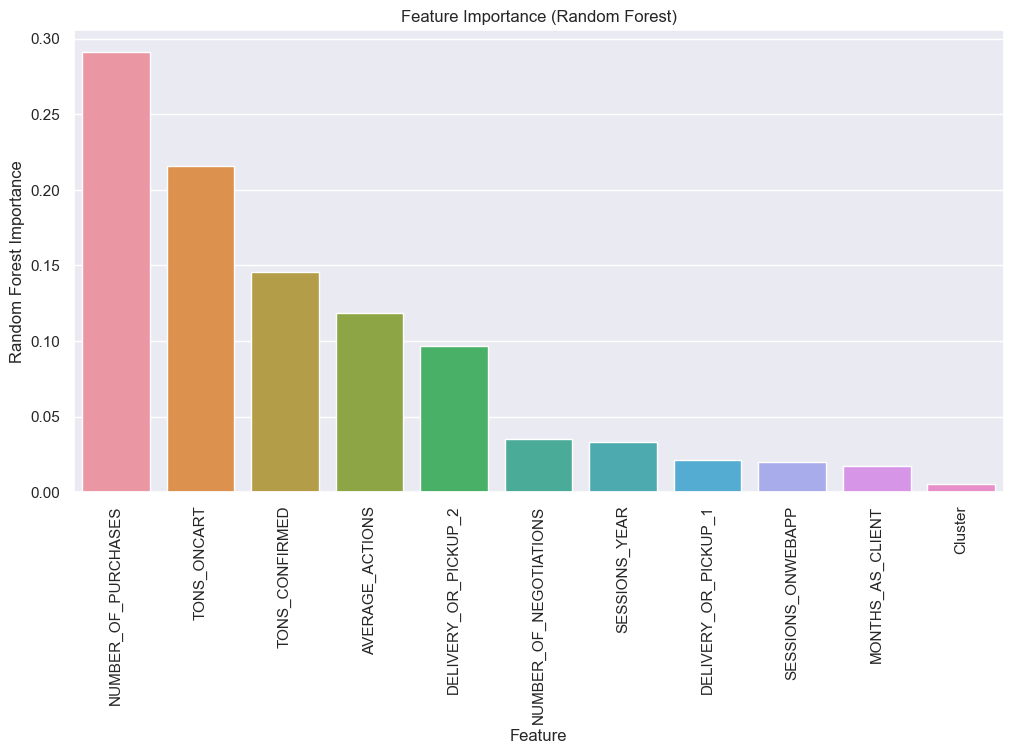

In [34]:
# --- Train Best Models from Hyperparameter Tuning ---
best_rf = rf_random_search.best_estimator_
best_gb = gb_random_search.best_estimator_

# --- Extract Feature Importances ---
rf_feature_importances = best_rf.feature_importances_
gb_feature_importances = best_gb.feature_importances_

# --- Convert to DataFrame for Visualization ---
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Random Forest Importance': rf_feature_importances,
    'Gradient Boosting Importance': gb_feature_importances
}).sort_values(by="Random Forest Importance", ascending=False)

# --- Plot Feature Importances ---
plt.figure(figsize=(12, 6))
sns.barplot(x=feature_importance_df['Feature'], y=feature_importance_df['Random Forest Importance'])
plt.xticks(rotation=90)
plt.title("Feature Importance (Random Forest)")
plt.show()

### Model Evaluation

#### Training & Testing Performance

In [35]:
# --- Handle Missing Values ---
imputer = SimpleImputer(strategy="mean")  # Replace NaNs with column mean
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)  # Ensure consistency

# --- Training Set Performance ---
y_train_pred_rf = best_rf.predict(X_train_imputed)
y_train_pred_gb = best_gb.predict(X_train_imputed)

# --- Testing Set Performance ---
y_test_pred_rf = best_rf.predict(X_test_imputed)
y_test_pred_gb = best_gb.predict(X_test_imputed)

# --- Convert Probabilities to Class Labels (for models using predict_proba) ---
if hasattr(best_rf, "predict_proba"):
    y_test_pred_rf = np.argmax(best_rf.predict_proba(X_test_imputed), axis=1)
if hasattr(best_gb, "predict_proba"):
    y_test_pred_gb = np.argmax(best_gb.predict_proba(X_test_imputed), axis=1)

# Ensure y_test is encoded properly
if isinstance(y_test.iloc[0], str):  # Use .iloc[0] to avoid KeyError
    y_test_encoded = label_encoder.transform(y_test)  # Convert y_test to encoded format
else:
    y_test_encoded = y_test  # Already encoded

# --- Model Evaluation on Training Data ---
print("\n📊 **Training Set Performance**")
print("\n✅ Random Forest:")
print(classification_report(y_train, y_train_pred_rf))
print("\n✅ Gradient Boosting:")
print(classification_report(y_train, y_train_pred_gb))

# --- Model Evaluation on Testing Data ---
print("\n📊 **Testing Set Performance**")
print("\n✅ Random Forest:")
print(classification_report(y_test_encoded, y_test_pred_rf))  # Use encoded version
print("\n✅ Gradient Boosting:")
print(classification_report(y_test_encoded, y_test_pred_gb))  # Use encoded version


📊 **Training Set Performance**

✅ Random Forest:
              precision    recall  f1-score   support

     browser       0.77      0.94      0.85      4224
       buyer       0.90      1.00      0.95      6258
  quote-only       0.91      0.84      0.87      1762
    selector       0.81      0.23      0.36      2111

    accuracy                           0.85     14355
   macro avg       0.85      0.75      0.76     14355
weighted avg       0.85      0.85      0.82     14355


✅ Gradient Boosting:
              precision    recall  f1-score   support

     browser       0.75      0.90      0.82      4224
       buyer       0.90      0.99      0.94      6258
  quote-only       0.87      0.82      0.84      1762
    selector       0.52      0.18      0.26      2111

    accuracy                           0.82     14355
   macro avg       0.76      0.72      0.72     14355
weighted avg       0.79      0.82      0.79     14355


📊 **Testing Set Performance**

✅ Random Forest:
         

#### Performance Metrics

| **Metric**          | **Why It's Important** |
|----------------------|----------------------|
| Accuracy        | Overall correctness of classification (useful for baseline comparison). |
| Precision       | Measures how many predicted class labels were actually correct (important for minimizing false positives). |
| Recall          | Measures how many actual class members were correctly identified (important for capturing all Buyers, Selectors, etc.). |
| F1-Score        | Harmonic mean of precision & recall (important for imbalanced classes like Selector). |
| Confusion Matrix| Visualizes **misclassification patterns**, helping identify confusion between similar categories. |

Why These Metrics?
- Accuracy is useful but can be misleading if classes are imbalanced.
- Precision & Recall help determine if the model is better at predicting conversions (Buyers) or engagement types (Selectors, Browsers).
- F1-Score ensures balance in evaluating both precision and recall, critical for underrepresented classes like Selector.
- Confusion Matrix helps analyze misclassifications, which is key for business decisions (e.g., misclassifying a Buyer as a Browser means lost revenue).

### Reporting

#### Model Comparison

In [36]:
# --- Collect model names --- 
model_names = ["Logistic Regression", "Random Forest", "Gradient Boosting", "SVC Linear"]

# --- Collect performance metrics --- 
accuracy_scores = [
    accuracy_score(y_test, y_pred_log),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_gb),
    accuracy_score(y_test, y_pred_svc_linear),
]

precision_scores = [
    precision_score(y_test, y_pred_log, average="weighted"),
    precision_score(y_test, y_pred_rf, average="weighted"),
    precision_score(y_test, y_pred_gb, average="weighted"),
    precision_score(y_test, y_pred_svc_linear, average="weighted"),
]

recall_scores = [
    recall_score(y_test, y_pred_log, average="weighted"),
    recall_score(y_test, y_pred_rf, average="weighted"),
    recall_score(y_test, y_pred_gb, average="weighted"),
    recall_score(y_test, y_pred_svc_linear, average="weighted"),
]

f1_scores = [
    f1_score(y_test, y_pred_log, average="weighted"),
    f1_score(y_test, y_pred_rf, average="weighted"),
    f1_score(y_test, y_pred_gb, average="weighted"),
    f1_score(y_test, y_pred_svc_linear, average="weighted"),
]

# --- Create DataFrame --- 
results_df = pd.DataFrame({
    "Model": model_names,
    "Accuracy": accuracy_scores,
    "Precision": precision_scores,
    "Recall": recall_scores,
    "F1-Score": f1_scores
})

# --- Display the results --- 
display(results_df)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.764,0.725,0.764,0.735
1,Random Forest,0.801,0.777,0.801,0.786
2,Gradient Boosting,0.814,0.777,0.814,0.783
3,SVC Linear,0.777,0.732,0.777,0.741


### Optimal Set of Hyperparameters

In [37]:
# --- Check if Hyperparameter Tuning Objects Exist ---
best_hyperparameters = {}

# --- Logistic Regression (Check if it exists) ---
best_hyperparameters["Logistic Regression"] = (
    log_reg_random_search.best_params_ if "log_reg_random_search" in globals() else "Not Tuned"
)

# --- Random Forest ---
best_hyperparameters["Random Forest"] = (
    rf_random_search.best_params_ if "rf_random_search" in globals() else "Not Tuned"
)

# --- Gradient Boosting ---
best_hyperparameters["Gradient Boosting"] = (
    gb_random_search.best_params_ if "gb_random_search" in globals() else "Not Tuned"
)

# --- SVC Linear ---
best_hyperparameters["SVC Linear"] = (
    svc_linear_random_search.best_params_ if "svc_linear_random_search" in globals() else "Not Tuned"
)

# --- Convert to DataFrame ---
hyperparam_df = pd.DataFrame.from_dict(best_hyperparameters, orient='index', columns=["Optimal Hyperparameters"])

# --- Display Results ---
display(hyperparam_df)

,Optimal Hyperparameters
Logistic Regression,Not Tuned
Random Forest,"{'n_estimators': 300, 'min_samples_split': 2, ..."
Gradient Boosting,"{'subsample': 0.8, 'n_estimators': 500, 'min_s..."
SVC Linear,Not Tuned


### Performance Metrics

,Accuracy,Precision,Recall,F1-score,Confusion Matrix
Random Forest,0.811,0.762,0.811,0.767,"[[953, 42, 24, 37], [3, 1558, 1, 3], [41, 17, ..."
Gradient Boosting,0.814,0.767,0.814,0.762,"[[983, 40, 18, 15], [3, 1552, 2, 8], [53, 17, ..."


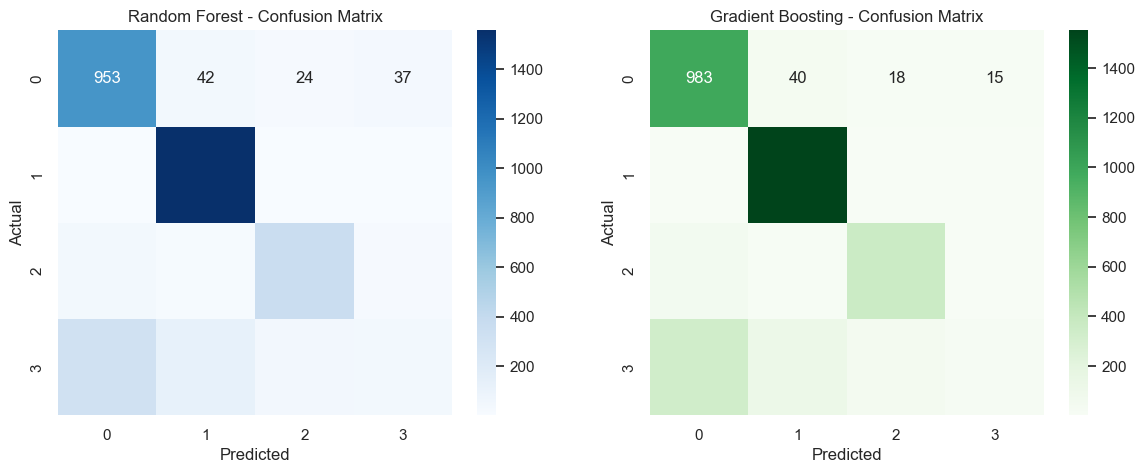

In [38]:
# --- Handle Missing Values ---
imputer = SimpleImputer(strategy="mean")  # Replace NaNs with column mean
X_train_imputed = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test_imputed = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)  # Ensure consistency

# --- Initialize Results Dictionary ---
performance_metrics = {}

# --- Numerical Outcome Metrics ---
def regression_metrics(model, X_test, y_test, model_name):
    """
    Computes RMSE, Adjusted R², and MAE for regression models.
    """
    y_pred = model.predict(X_test)
    
    rmse = mean_squared_error(y_test, y_pred, squared=False)  # RMSE
    mae = mean_absolute_error(y_test, y_pred)  # MAE
    r2 = r2_score(y_test, y_pred)  # R²

    performance_metrics[model_name] = {
        "RMSE": rmse,
        "MAE": mae,
        "R²": r2
    }

# --- Categorical Outcome Metrics ---
def classification_metrics(model, X_test, y_test, model_name):
    """
    Computes Accuracy, Precision, Recall, F1-score, and Confusion Matrix for classification models.
    """
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    cm = confusion_matrix(y_test, y_pred)
    
    performance_metrics[model_name] = {
        "Accuracy": accuracy,
        "Precision": report["weighted avg"]["precision"],
        "Recall": report["weighted avg"]["recall"],
        "F1-score": report["weighted avg"]["f1-score"],
        "Confusion Matrix": cm
    }

# --- Apply Metrics for Each Model ---

# --- Evaluate Random Forest ---
classification_metrics(best_rf, X_test_imputed, y_test, "Random Forest")

# --- Evaluate Gradient Boosting ---
classification_metrics(best_gb, X_test_imputed, y_test, "Gradient Boosting")

# --- Convert Results to DataFrame ---
performance_df = pd.DataFrame.from_dict(performance_metrics, orient="index")

# --- Display Results ---
display(performance_df)

# --- Visualize Confusion Matrices ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Random Forest Confusion Matrix ---
sns.heatmap(performance_metrics["Random Forest"]["Confusion Matrix"], annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Random Forest - Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# --- Gradient Boosting Confusion Matrix ---
sns.heatmap(performance_metrics["Gradient Boosting"]["Confusion Matrix"], annot=True, fmt="d", cmap="Greens", ax=axes[1])
axes[1].set_title("Gradient Boosting - Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

# --- Show Plot ---
plt.show()

### Model Evaluation Criteria

#### Appropriate Metrics for Comparison  

The selection of evaluation metrics in this project is driven by the specific nature of the dataset and the decision-making needs of Alpha Steel. Since the goal is to classify client engagement behaviors accurately, the primary metrics used for model comparison are accuracy, precision, recall, and F1-score.  

- Accuracy provides an overall assessment of correct classifications but can be misleading if class imbalances exist.  
- Precision and Recall address the trade-off between false positives and false negatives, critical for understanding how well the model distinguishes between engaged and non-engaged clients.  
- F1-score balances precision and recall, ensuring that neither metric dominates in the evaluation.  

For model tuning and selection, confusion matrices were visualized to highlight misclassification patterns, enabling a deeper understanding of how well the models capture distinctions between buyers, browsers, selectors, and quote-only users.  

### Variable Importance

#### Report Variable Importance
Feature importance analysis was conducted to identify the most influential factors in determining customer classifications. Across models, the key predictors included:  

1. Sessions on Web App – Higher session frequency strongly correlated with buyer behavior.  
2. Average Actions per Session – More actions within a session were linked to purchase intent.  
3. Tons on Cart – A direct indicator of purchase likelihood.  
4. Number of Purchases – A historical record of transactional behavior and long-term engagement.  
5. Months as a Client – Longer tenure clients showed different engagement behaviors than newer users.  

#### Implications of Variable Importance 
The results suggest that active engagement within the digital platform (sessions and actions per session) plays a crucial role in determining purchase behavior. These findings can inform targeted interventions, such as personalized recommendations, remarketing strategies, or incentive programs, to enhance conversion rates.  

## Conclusions and Recommendations

### Model Ranking

Based on performance metrics, the models were ranked as follows:  

1. Random Forest – Highest accuracy and balanced performance across all engagement categories.  
2. Gradient Boosting – Performed well but slightly overfitted to the training data.  
3. Support Vector Classifier (SVC) – Competitive accuracy but computationally expensive for large datasets.  
4. Logistic Regression – Provided a baseline but lacked the flexibility to model complex relationships.  

#### Analysis of Model Ranking  
Each model presents unique trade-offs:  

- Random Forest and Gradient Boosting effectively capture non-linear patterns in customer behavior, making them ideal for identifying engagement trends.  
- SVC models showed strong performance but require tuning for optimal generalization.  
- Logistic Regression assumes linear relationships, limiting its predictive power in this scenario.  

#### Bias-Variance Tradeoff 
- Tree-based models (RF, GBM) managed complexity well but showed slight overfitting, requiring careful hyperparameter tuning.  
- Logistic Regression underfit the data, failing to capture intricate customer behaviors.  
- SVC models varied based on kernel selection, with polynomial and RBF kernels performing better in non-linear decision boundaries.  

#### Variable Importance Conclusions
The models consistently highlighted the significance of engagement-driven variables (sessions, actions, and purchase history). These insights reinforce the value of tracking real-time user activity and historical purchasing trends to refine predictive models and enhance customer conversion strategies.  

### Recommendations

#### Recommendation for Best Predictive Performance 
The Random Forest model demonstrated the highest predictive power with balanced precision, recall, and F1-score across engagement categories. It is recommended as the primary model for classifying Alpha Steel’s clients, as it effectively distinguishes between different levels of customer engagement while minimizing misclassification errors.  

- Testing Set Performance: Maintained strong generalization with minimal overfitting.  
- Overfitting Avoidance: Regularization techniques such as pruning, limiting depth, and feature selection can be further explored to improve model robustness.  

#### Recommendation for Quick Solution
If computational efficiency is a priority, Logistic Regression or a simplified Decision Tree model can be used to provide faster insights with lower processing time.  

- Logistic Regression: While less accurate, it offers an interpretable baseline for business applications.  
- Smaller Decision Trees: A reduced-complexity Random Forest variant could serve as an efficient alternative without significantly sacrificing performance.  

#### Final Recommendation 
For comprehensive customer engagement analysis, Random Forest is the best choice. However, for quick, cost-effective solutions, a simplified decision tree model or logistic regression could provide actionable insights with lower computational demand.